# EDA-анализ набора данных

Описание вводной информации:
1. Для анализа предоставлен обезличенный временной ряд,
2. Данные с шагом 20 секунд,
3. На данных был построен поиск аномалий, но не исключено построение регрессии.

## 1. Загрузка и ознакомление с данными

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean
from statsmodels.robust.scale import mad
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.fft import fft, fftfreq
import scipy.stats as st
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# загрузка файла
df = pd.read_csv('C:/Users/FokinDV/Desktop/Data Science/Работа на 25.08.2025/for_research.csv')

### 1.1 Обзор основной информации датасета, поиск пропусков, дубликатов

In [3]:
# обзор основной информации датасета, ищем пропуски, дубликаты
display(df.columns)
display(df.info())
display(df.describe())
display(df.head(10))
display(df.tail(10))
display(df.isna().sum())
display(df.isnull().sum())
display(df.duplicated().sum())

Index(['Unnamed: 0', 'column1', 'column2', 'column3'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499999 entries, 0 to 499998
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  499999 non-null  int64  
 1   column1     499999 non-null  float64
 2   column2     499999 non-null  float64
 3   column3     499999 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 15.3 MB


None

,Unnamed: 0,column1,column2,column3
count,499999.00000,4.999990e+05,4.999990e+05,4.999990e+05
mean,249999.00000,-4.172315e-17,2.279426e-16,-8.889305e-15
std,144337.42296,1.000001e+00,1.000001e+00,1.000001e+00
min,0.00000,-1.239700e+00,-2.242911e+00,-2.064320e+00
25%,124999.50000,-7.584920e-01,-9.428091e-01,-8.447486e-01
50%,249999.00000,-7.051186e-01,6.508593e-02,-1.858723e-02
75%,374998.50000,1.049378e+00,8.170989e-01,1.017393e+00
max,499998.00000,1.967720e+00,2.052058e+00,2.066487e+00


,Unnamed: 0,column1,column2,column3
0,0,1.146557,0.970044,-0.988999
1,1,1.146547,0.969740,-0.993370
2,2,1.146504,0.971344,-0.997742
3,3,1.146412,0.969045,-1.002113
4,4,1.146768,0.973520,-0.997742
5,5,1.146786,0.969831,-0.993370
6,6,1.146521,0.969122,-0.988999
7,7,1.146375,0.970724,-0.988999
8,8,1.146233,0.968294,-0.988999
9,9,1.146247,0.970102,-0.988999


,Unnamed: 0,column1,column2,column3
499989,499989,-1.210294,-1.560141,1.397689
499990,499990,-1.210543,-1.560950,1.397689
499991,499991,-1.210409,-1.557099,1.397689
499992,499992,-1.210355,-1.557941,1.397689
499993,499993,-1.210465,-1.561469,1.397689
499994,499994,-1.210662,-1.559794,1.397689
499995,499995,-1.210814,-1.559230,1.397689
499996,499996,-1.210646,-1.557575,0.663324
499997,499997,-1.210505,-1.560759,-0.071042
499998,499998,-1.210541,-1.559174,-0.805408


Unnamed: 0    0
column1       0
column2       0
column3       0
dtype: int64

Unnamed: 0    0
column1       0
column2       0
column3       0
dtype: int64

0

In [4]:
# переименовываем столбцы, устанавливаем индекс
df = df.rename(columns={'Unnamed: 0': 'time_row'})
df = df.set_index('time_row')
display(df.head(10))

,column1,column2,column3
time_row,,,
0,1.146557,0.970044,-0.988999
1,1.146547,0.969740,-0.993370
2,1.146504,0.971344,-0.997742
3,1.146412,0.969045,-1.002113
4,1.146768,0.973520,-0.997742
5,1.146786,0.969831,-0.993370
6,1.146521,0.969122,-0.988999
7,1.146375,0.970724,-0.988999
8,1.146233,0.968294,-0.988999


### 1.2 Построение гистограмм по признакам

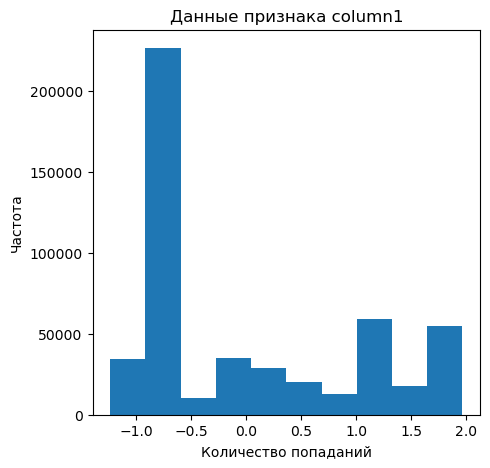

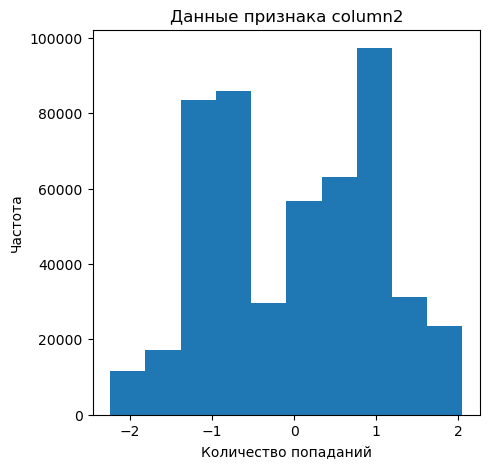

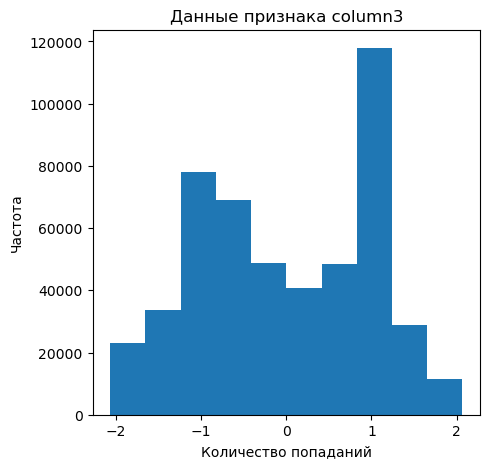

In [5]:
# смотрим и анализируем гисторграммы по признакам
ax = df['column1'].plot.hist(figsize=(5,5))
ax.set_xlabel('Количество попаданий')
ax.set_ylabel('Частота')
plt.title('Данные признака column1')
plt.show()

ax = df['column2'].plot.hist(figsize=(5,5))
ax.set_xlabel('Количество попаданий')
ax.set_ylabel('Частота')
plt.title('Данные признака column2')
plt.show()

ax = df['column3'].plot.hist(figsize=(5,5))
ax.set_xlabel('Количество попаданий')
ax.set_ylabel('Частота')
plt.title('Данные признака column3')
plt.show()

### 1.3 Построение боксплотов по признакам

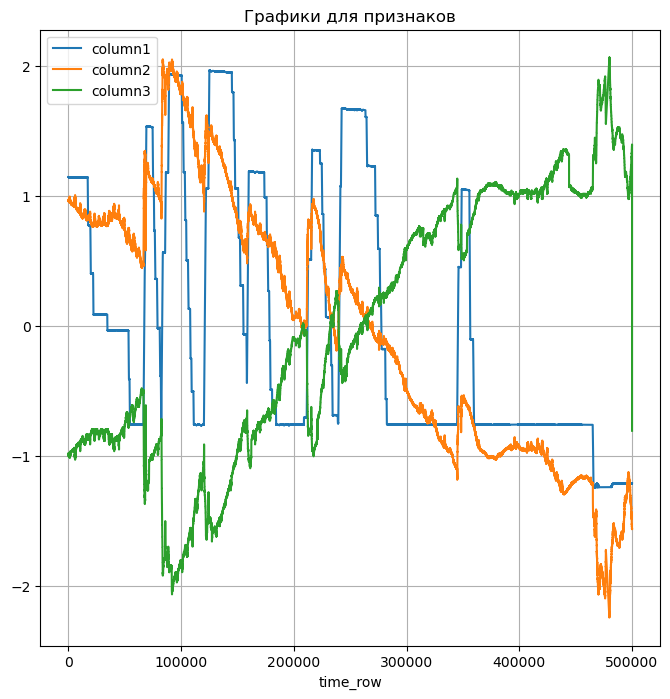

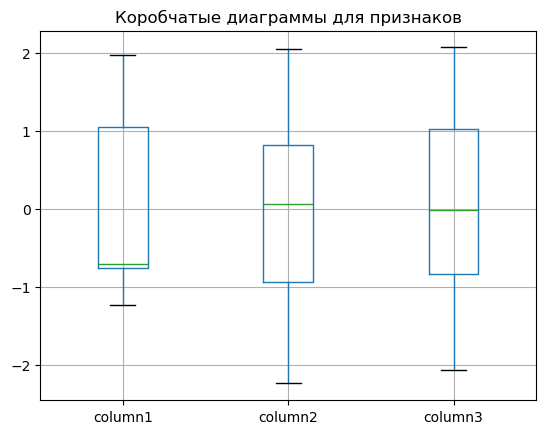

In [6]:
# смотрим и анализируем боксплоты по признакам
df.plot(grid=True, figsize=(8,8))
plt.title('Графики для признаков')
plt.show()
df.boxplot(grid=True)
plt.title('Коробчатые диаграммы для признаков')
plt.show()

### 1.4 Построение матрицы корреляций по признакам

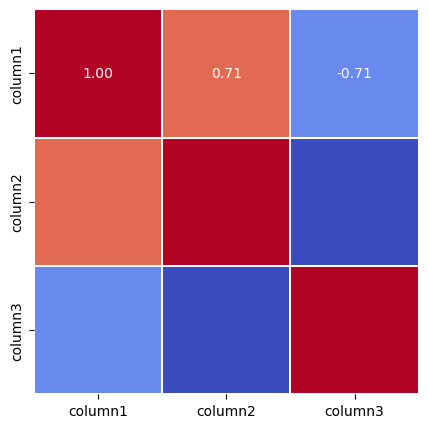

In [7]:
# строим матрицу корреляций по признакам
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()

In [8]:
display(df.corr())

,column1,column2,column3
column1,1.000000,0.714711,-0.708750
column2,0.714711,1.000000,-0.995637
column3,-0.708750,-0.995637,1.000000


### 1.5 Обзор ключевых статистик по признакам

In [9]:
# выведем ключевые статистики по трем признакам выборки
data = {'Статистика':['Среднее', 'Усеченное среднее', 'Медиана', 'Медианное абсолютное отклонение', 'Стандартное отклонение', 'Стандартная ошибка', 'Дисперсия'],
       'column1':[df['column1'].mean(), trim_mean(df['column1'], 0.1), df['column1'].median(), mad(df['column1']), np.std(df['column1'], ddof=1), np.std(df['column1'], ddof=1)/np.sqrt(len(df['column1'])), np.var(df['column1'])],
       'column2':[df['column2'].mean(), trim_mean(df['column2'], 0.1), df['column2'].median(), mad(df['column2']), np.std(df['column2'], ddof=1), np.std(df['column2'], ddof=1)/np.sqrt(len(df['column2'])), np.var(df['column2'])],
       'column3':[df['column3'].mean(), trim_mean(df['column3'], 0.1), df['column3'].median(), mad(df['column3']), np.std(df['column3'], ddof=1), np.std(df['column3'], ddof=1)/np.sqrt(len(df['column3'])), np.var(df['column3'])]}
data_table = pd.DataFrame(data)
data_table = data_table.round(5)
pivot_table = pd.pivot_table(data_table,
                             columns='Статистика',
                             values=['column1', 'column2', 'column3'],
                            sort=False)
display(pivot_table)

Статистика,Среднее,Усеченное среднее,Медиана,Медианное абсолютное отклонение,Стандартное отклонение,Стандартная ошибка,Дисперсия
column1,0.0,-0.09621,-0.70512,0.75044,1.0,0.00141,1.0
column2,0.0,-0.01171,0.06509,1.25304,1.0,0.00141,1.0
column3,0.0,0.02630,-0.01859,1.32208,1.0,0.00141,1.0


### 1.6 Вывод

1. В данных отсутствуют пропуски и дублирования,
2. Стандартные ошибки, отклонения, дисперсии находятся достаточно близко друг к другу в указанных признаках,
3. Медианное абсолютное отклонение второго и третьего признаков находятся достаточно близко, можно предположить, что признаки имеют схожесть,
4. Корреляции:
   - первый признак column1: сильная прямая корреляция со вторым признаком column2 - 0,71, сильная обратная корреляция с третьим признаком column3 - -0,71,
   - второй признак column2: сильная прямая корреляция с первым признаком column1 - 0,71, сильная обратная корреляция с третьим признаком column3 - -0,99,
   - третий признак column3: сильная обратная корреляция с первым признаком column1 - -0,71, сильная обратная корреляция со вторым признаком column2 - -0,99.

## 2. SSA анализ

## 2.1 Применение SSA

Следует отметить, что приведенный ниже пример кода может использоваться как для разложения данных по одному признаку, так и по нескольким в отдельности, но в случае применения данного метода к каждому признаку в отдельности может потеряться информация о корреляции признаков и тогда рекомендуют использовать MSSA-анализ, либо PCA + SSA.

In [10]:
class SSA(object):
    __supported_types = (pd.Series, np.ndarray, list)
    def __init__(self, tseries, L, save_mem=True):
        """
        Класс выполняет декомпозицию временного ряда с помощью анализа сингулярного спектра.
        Предполагается, что значения временного ряда записываются через равные промежутки времени.
        
        Принимает параметры:
        - tseries: DataFrame, np.array, list.
            Получение исходного временного ряда.
        - L: int.
            Длина окна. 2 <= L <= N/2, N - длина временного ряда.
            Значение >= 2.
        - save_mem: bool.
            Позволяет экономить память, не сохраняя сгенерированные матрицы. Только для длинных временных рядов со значениями более 1000.
            По умолчанию значение True.
        """
        # Проверка типа входных данных
        if not isinstance(tseries, self.__supported_types):
            raise TypeError('Неподдерживаемый объект, попробуйте формат DataFrame, np.array, list')

        # Проверка значения величины окна L
        self.N = len(tseries)
        if not 2 <= L <= self.N/2:
            raise ValueError('Величина окна должна быть в интервале между (2, N/2).')

        # Задаем значение величины окна
        self.L = L
        self.orig_TS = pd.Series(tseries) # оригинальный временной ряд, как эталон для сравнения реконструкции
        self.K = self.N - self.L + 1 # количество векторов-строк траекторной матрицы

        # Вставляем временной ряд в матрицу траекторий,
        # транспонирование матрицы траекторий, сформированной из временного ряда
        self.X = np.array([self.orig_TS.values[i:L+i] for i in range(0, self.K)]).T

        # Разложение матрицы траекторий на компоненты:
        # - U - матрица левых сингулярных векторов(L*L)(форма базисных функций)
        # - E - диагональная матрица сингулярных значений(L*K)(важность каждой компоненты)
        # - V^T - транспонированная матрица правых сингулярных векторов(K*K)(коэффициенты разложения)
        self.U, self.Sigma, VT = np.linalg.svd(self.X, full_matrices=False) # full_matrices=False - добавил для экономии ресурса
        # Ранг матрицы
        self.d = np.linalg.matrix_rank(self.X)
        # Для экономии памяти вместо L компонентов - d компонентов
        self.TS_comps = np.zeros((self.N, self.d))
        
        # Если не экономим память
        if not save_mem:
            # Построим и сохраним все элементарные матрицы
            self.X_elem = np.array([ self.Sigma[i]*np.outer(self.U[:,i], VT[i,:]) for i in range(self.d) ])

            # Усреднение элементарных матриц по диагонали, сохранение их в виде столбцов массива           
            for i in range(self.d):
                X_rev = self.X_elem[i, ::-1]
                self.TS_comps[:,i] = [X_rev.diagonal(j).mean() for j in range(-X_rev.shape[0]+1, X_rev.shape[1])]
            # Матрица правых сингулярных векторов
            self.V = VT.T
        else:
            # Реконструкция элементарных матриц не сохраняя их
            for i in range(self.d):
                X_elem = self.Sigma[i]*np.outer(self.U[:,i], VT[i,:])
                X_rev = X_elem[::-1]
                self.TS_comps[:,i] = [X_rev.diagonal(j).mean() for j in range(-X_rev.shape[0]+1, X_rev.shape[1])]
            
            self.X_elem = 'Перезапустите функцию с save_mem=False, чтобы сохранить элементарные матрицы.'
            
            # Массив может быть очень большим, не сохраняем его
            self.V = 'Перезапустите функцию с save_mem=False, чтобы сохранить матрицу V.'
        
        # Расчет взвешенной корреляции
        self.calc_wcorr()
            
    def components_to_df(self, n=0):
        """
        Компановка всех компонентов в DataFrame.

        Принимает параметры:
        - n: int.
        Возвращает:
        - DataFrame.
        """
        if n > 0:
            n = min(n, self.d)
        else:
            n = self.d
        
        # Создание списка столбцов с названиями F0, F1, F2, ...
        cols = ['F{}'.format(i) for i in range(n)]
        return pd.DataFrame(self.TS_comps[:, :n], columns=cols, index=self.orig_TS.index)
            
    
    def reconstruct(self, indices):
        """
        Восстановление временного ряда из его элементарных компонентов, используя заданные индексы.

        Принимает параметры:
        - indices: int, list, slice(n,m) object.
        Возвращает:
        - series, DataFrame.
        """
        if isinstance(indices, int): indices = [indices]
        
        ts_vals = self.TS_comps[:,indices].sum(axis=1)
        return pd.Series(ts_vals, index=self.orig_TS.index)
    
    def calc_wcorr(self):
        """
        Вычисляет взвешенную матрицу корреляций временного ряда.
        """
        # Расчет весов для компенсации разного количества диагоналей
        w = np.array(list(np.arange(self.L)+1) + [self.L]*(self.K-self.L-1) + list(np.arange(self.L)+1)[::-1])
        # Взвешенное скалярное произведение
        def w_inner(F_i, F_j):
            return w.dot(F_i*F_j)
        
        # Вычисление взвешенных норм, ||F_i||_w, затем инвертирование.
        F_wnorms = np.array([w_inner(self.TS_comps[:,i], self.TS_comps[:,i]) for i in range(self.d)])
        F_wnorms = F_wnorms**-0.5
        
        # Расчет взвешенной корреляции
        self.Wcorr = np.identity(self.d)
        for i in range(self.d):
            for j in range(i+1,self.d):
                self.Wcorr[i,j] = abs(w_inner(self.TS_comps[:,i], self.TS_comps[:,j]) * F_wnorms[i] * F_wnorms[j])
                self.Wcorr[j,i] = self.Wcorr[i,j]
    
    def plot_wcorr(self, min=None, max=None):
        """
        Строит взвешенную матрицу корреляций для разложенного временного ряда.

        Принимает параметры:
        - min: int.
            Минимальное количество компонентов.
        - max: int.
            Максимальное количество компонентов.            
        Возвращает:
        - графические элементы.
        """
        # Задаем параметры мин и макс для больших матриц корреляций
        if min is None:
            min = 0
        if max is None:
            max = self.d
        # Вычисление взвешенной корреляции
        if self.Wcorr is None:
            self.calc_wcorr()
        # Создание тепловой карты из матрицы
        ax = plt.imshow(self.Wcorr)
        plt.xlabel(r"$\tilde{F}_i$")
        plt.ylabel(r"$\tilde{F}_j$")
        plt.colorbar(ax.colorbar, fraction=0.045)
        ax.colorbar.set_label("$W_{i,j}$")
        plt.clim(0,1)
        
        # Границы отображения
        if max == self.d:
            max_rnge = self.d-1
        else:
            max_rnge = max
        # Центрирование
        plt.xlim(min-0.5, max_rnge+0.5)
        plt.ylim(max_rnge+0.5, min-0.5)

In [11]:
# функция исследования признаков
def research_signs(data, l):
    # Раскладываем на компоненты, выбираем рекомендуемый для тестирования и минимальных промежутков размер окна L
    print(f'Разложение на компоненты признака {data.name}\n')
    ssa_df_column = SSA(data, l, save_mem=True)
    components_df_column = ssa_df_column.components_to_df()
    display(components_df_column)
    display(components_df_column.describe())

    # Строим графики для разложенных компонентов признака
    print(f'Строим графики для разложенных компонентов признака {data.name}\n')
    components_df_column.reset_index(drop=True).plot(grid=True, figsize=(5,5))
    plt.title(f'Графики для разложенных компонентов признака {data.name} c L={l}')
    plt.show()

    # Проверка размера данных при L для контроля
    print(f'Проверка размера данных при L для контроля {data.name}\n')
    display(ssa_df_column.TS_comps.shape)
        
    # Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака
    print(f'Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака {data.name}\n')
    ssa_df_column.plot_wcorr(0,l)
    plt.title(f'Матрица взвешенной корреляции компонентов признака {data.name} c L={l}')
    plt.show()

    # Ранжируем компоненты по убыванию важности
    print(f'Ранжируем компоненты по убыванию важности признака {data.name}\n')    
    sigma_column = ssa_df_column.Sigma
    sigma_column = sigma_column / sigma_column.sum()

    if l <= 3:
        # Визуализация первых 3х компонентов
        print(f'Визуализация первых 3х компонент признака {data.name}\n')
        plt.plot(sigma_column[:3])
        plt.title('Визуализация первых трех компонент по убыванию важности')
        plt.show()
        
        # Показывает какое количество компонент объясняет основной процент информации
        print(f'Показывает какое количество компонент объясняет основной процент информации\n')
        display(sigma_column[:1].sum(), sigma_column[2:].sum())

        # Показывает сколько компонент необходимо для заданного процента информации
        print(f'Показывает сколько компонент необходимо для заданного процента информации\n')
        plt.plot(sigma_column.cumsum())
        plt.title('Показывает сколько компонент необходимо для заданного процента информации')
        plt.show()

        # Реконструкция данных:
        # - F0 - тренд,
        # - F1, F2 - основные парные компоненты цикличности,
        # - F3, F4 - дополнительные парные компоненты цикличености,
        # - F5, F6 - цикличность более высокого масштаба,
        # - F7, F*** - вероятно, шум и случайные колебания.
        print(f'Реконструкция данных\n')
        ssa_df_column.reconstruct(0).plot(grid=True, figsize=(5,5))
        plt.title('Основной компонент цикличности/тренда')
        plt.show()
        ssa_df_column.reconstruct(1).plot(grid=True, figsize=(5,5))
        plt.title('Второй компонент, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct(2).plot(grid=True, figsize=(5,5))
        plt.title('Третий компонент, шум/остаток')
        plt.show()

    elif 7 > l > 3:
        # Визуализация первых 6 компонентов
        print(f'Визуализация первых 6 компонент признака {data.name}\n')
        plt.plot(sigma_column[:6])
        plt.title('Визуализация первых 6 компонент по убыванию важности')
        plt.show()

        # Показывает какое количество компонент объясняет основной процент информации
        print(f'Показывает какое количество компонент объясняет основной процент информации\n')
        display(sigma_column[:1].sum(), sigma_column[2:3].sum(), sigma_column[4:].sum())

        # Показывает сколько компонентов необходимо для заданного процента информации
        print(f'Показывает сколько компонент необходимо для заданного процента информации\n')
        plt.plot(sigma_column.cumsum())
        plt.title('Показывает сколько компонент необходимо для заданного процента информации')
        plt.show()

        # Реконструкция данных:
        # - F0 - тренд,
        # - F1, F2 - основные парные компоненты цикличности,
        # - F3, F4 - дополнительные парные компоненты цикличености,
        # - F5, F6 - цикличность более высокого масштаба,
        # - F7, F*** - вероятно, шум и случайные колебания.
        print(f'Реконструкция данных\n')
        ssa_df_column.reconstruct(0).plot(grid=True, figsize=(5,5))
        plt.title('Основной компонент цикличности')
        plt.show()
        ssa_df_column.reconstruct([1,2]).plot(grid=True, figsize=(5,5))
        plt.title('2-3 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([3,5]).plot(grid=True, figsize=(5,5))
        plt.title('4-6 компоненты, шум/остаток')
        plt.show()
    elif l > 7:
        # Визуализация первых 12 компонент
        print(f'Визуализация первых 12 компонент признака {data.name}\n')
        plt.plot(sigma_column[:12])
        plt.title('Визуализация первых 12 компонент по убыванию важности')
        plt.show()

        # Показывает какое количество компонент объясняет основной процент информации
        print(f'Показывает какое количество компонент объясняет основной процент информации\n')
        display(sigma_column[:1].sum(), sigma_column[2:3].sum(), sigma_column[4:8].sum(), sigma_column[9:12].sum())
        
        # Показывает сколько компонентов необходимо для заданного процента информации
        print(f'Показывает сколько компонент необходимо для заданного процента информации\n')
        plt.plot(sigma_column.cumsum())
        plt.title('Показывает сколько компонент необходимо для заданного процента информации')
        plt.show()

        # Реконструкция данных:
        # - F0 - тренд,
        # - F1, F2 - основные парные компоненты цикличности,
        # - F3, F4 - дополнительные парные компоненты цикличености,
        # - F5, F6 - цикличность более высокого масштаба,
        # - F7, F*** - вероятно, шум и случайные колебания.
        print(f'Реконструкция данных\n')
        ssa_df_column.reconstruct(0).plot(grid=True, figsize=(5,5))
        plt.title('Основной компонент цикличности')
        plt.show()
        ssa_df_column.reconstruct([1,2]).plot(grid=True, figsize=(5,5))
        plt.title('2-3 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([3,4]).plot(grid=True, figsize=(5,5))
        plt.title('4-5 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([5,6]).plot(grid=True, figsize=(5,5))
        plt.title('6-7 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([7,11]).plot(grid=True, figsize=(5,5))
        plt.title('8-12 компоненты, шум/остаток')
        plt.show()


## 2.2 Исследование признаков через SSA

### 2.2.1 Исследуем первый признак(column1)

#### 2.2.1.1 Обзор первого признака

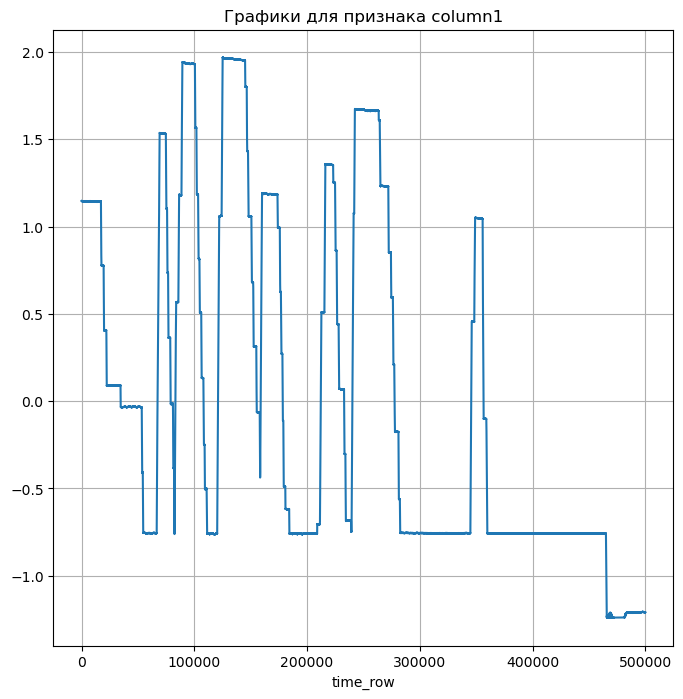

In [12]:
# Строим график для первого признака
df['column1'].plot(grid=True, figsize=(8,8))
plt.title('Графики для признака column1')
plt.show()

#### 2.2.1.2 Параметры признака column1 при L=3

Разложение на компоненты признака column1



,F0,F1,F2
time_row,,,
0,1.146536,0.000027,-0.000005
1,1.146512,0.000034,0.000001
2,1.146528,-0.000053,0.000029
3,1.146568,-0.000085,-0.000071
4,1.146636,0.000085,0.000047
...,...,...,...
499994,-1.210616,-0.000054,0.000008
499995,-1.210670,-0.000110,-0.000034
499996,-1.210642,-0.000015,0.000011


,F0,F1,F2
count,4.999990e+05,4.999990e+05,4.999990e+05
mean,-1.532206e-10,1.806623e-10,-2.744137e-11
std,1.000001e+00,8.811295e-05,7.313249e-05
min,-1.239700e+00,-7.702204e-03,-8.291394e-03
25%,-7.584980e-01,-3.624003e-05,-1.676999e-05
50%,-7.050968e-01,-1.879077e-14,-4.710517e-16
75%,1.049395e+00,3.561634e-05,1.687781e-05
max,1.967634e+00,7.825798e-03,8.299342e-03


Строим графики для разложенных компонентов признака column1



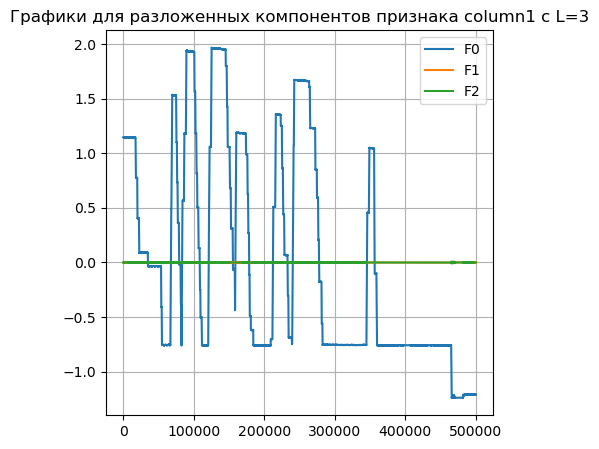

Проверка размера данных при L для контроля column1



(499999, 3)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column1



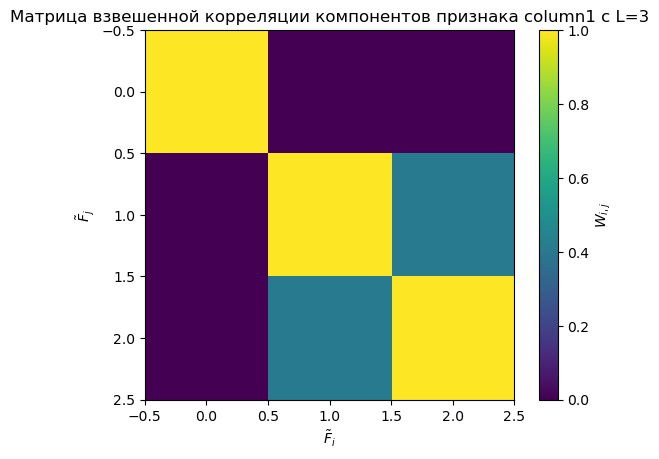

Ранжируем компоненты по убыванию важности признака column1

Визуализация первых 3х компонент признака column1



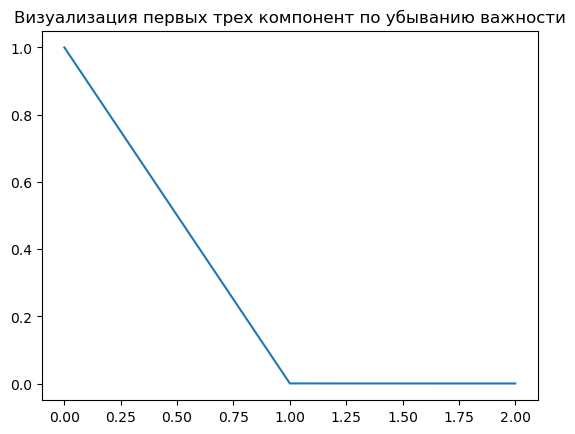

Показывает какое количество компонент объясняет основной процент информации



0.9996518393012125

9.485060094823487e-05

Показывает сколько компонент необходимо для заданного процента информации



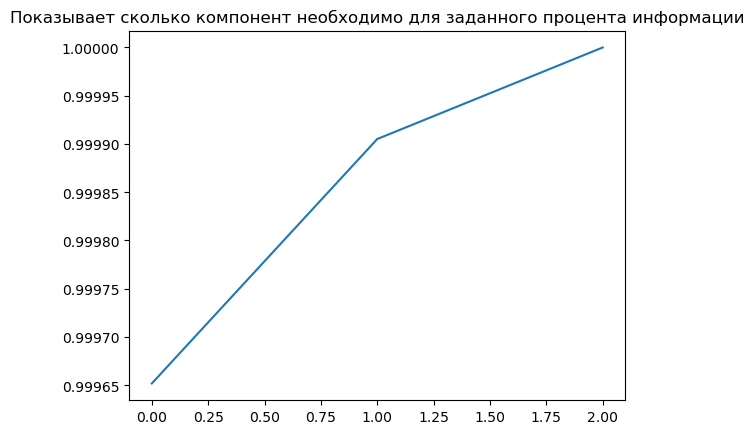

Реконструкция данных



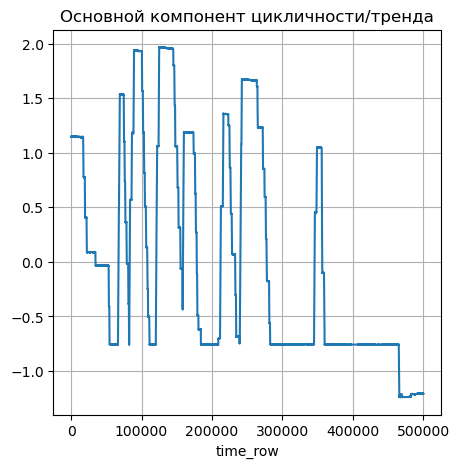

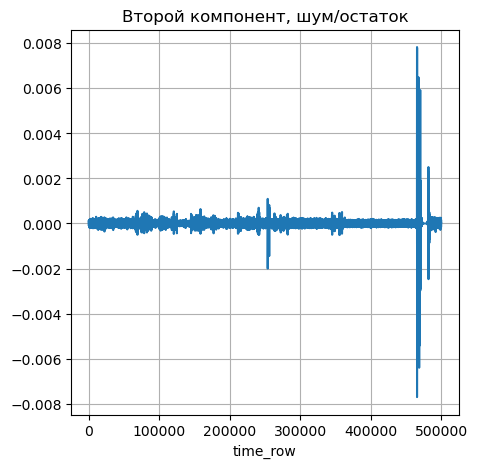

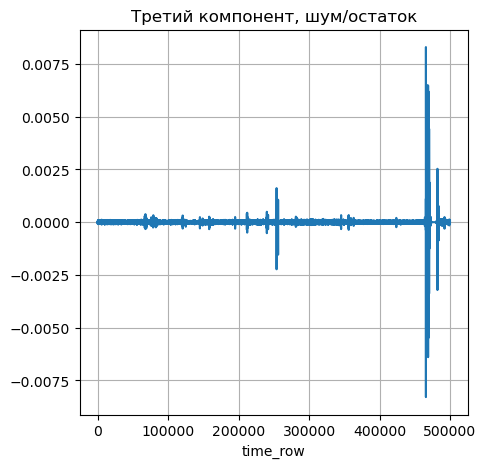

In [13]:
research_signs(df['column1'], 3)

#### 2.2.1.3 Вывод

Был исследован через SSA признак column1, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F2. Этот компонент объясняет 99% изменений временного ряда признака column1.

#### 2.1.1.4 Параметры признака column1 при L=6

Разложение на компоненты признака column1



,F0,F1,F2,F3,F4,F5
time_row,,,,,,
0,1.146595,-0.000121,0.000107,-0.000004,-0.000031,0.000011
1,1.146592,-0.000077,-0.000016,0.000054,0.000019,-0.000026
2,1.146582,-0.000018,-0.000091,-0.000029,0.000023,0.000037
3,1.146565,0.000047,-0.000060,-0.000058,-0.000046,-0.000036
4,1.146550,0.000103,0.000045,0.000022,0.000026,0.000022
...,...,...,...,...,...,...
499994,-1.210547,-0.000047,-0.000043,-0.000045,0.000011,0.000010
499995,-1.210570,-0.000076,-0.000100,-0.000041,-0.000013,-0.000014
499996,-1.210580,-0.000085,-0.000032,0.000031,0.000007,0.000013


,F0,F1,F2,F3,F4,F5
count,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05
mean,2.745291e-10,-4.313644e-10,2.201224e-10,-3.533338e-11,-3.388639e-11,5.931751e-12
std,1.000001e+00,9.789901e-05,6.426808e-05,4.380713e-05,4.025012e-05,4.671412e-05
min,-1.239700e+00,-8.050968e-03,-5.738618e-03,-4.062190e-03,-3.717413e-03,-4.392565e-03
25%,-7.585076e-01,-4.741691e-05,-2.986895e-05,-1.437769e-05,-8.136613e-06,-1.071010e-05
50%,-7.050805e-01,-8.253150e-14,-9.998996e-15,-2.217396e-17,-2.816364e-16,-1.872817e-20
75%,1.049405e+00,4.657904e-05,2.960905e-05,1.441585e-05,8.174870e-06,1.070896e-05
max,1.967519e+00,7.212541e-03,5.709301e-03,4.266823e-03,3.506178e-03,4.444027e-03


Строим графики для разложенных компонентов признака column1



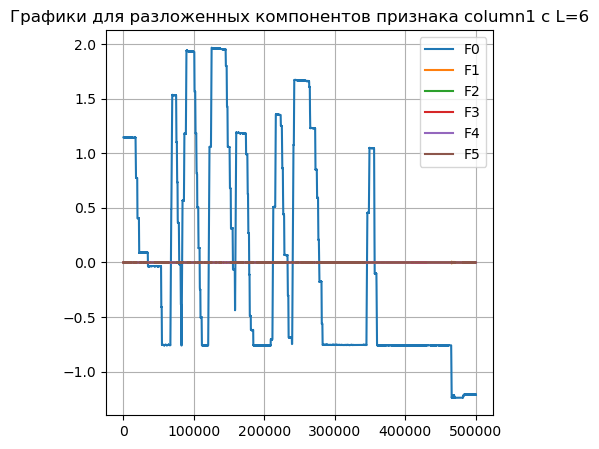

Проверка размера данных при L для контроля column1



(499999, 6)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column1



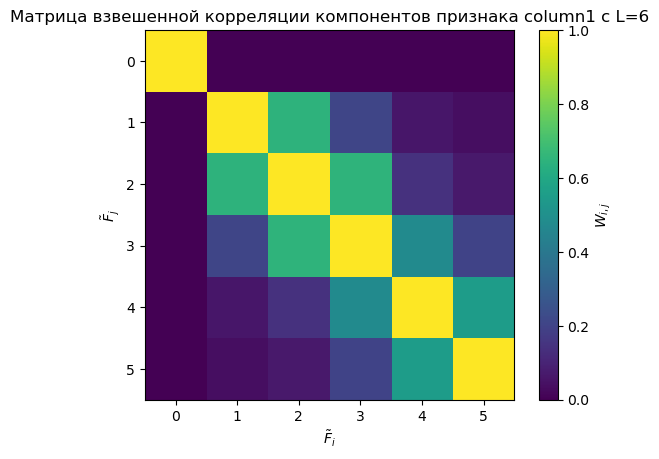

Ранжируем компоненты по убыванию важности признака column1

Визуализация первых 6 компонент признака column1



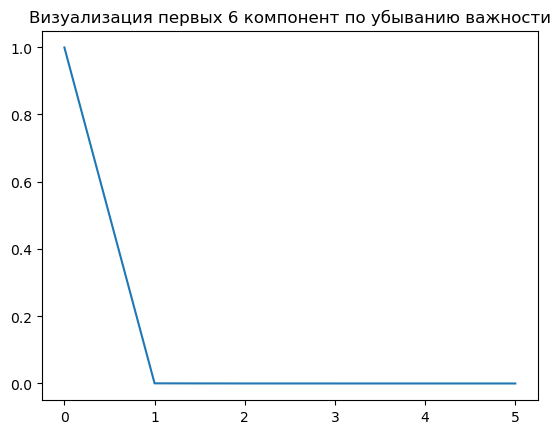

Показывает какое количество компонент объясняет основной процент информации



0.9992141649635448

0.00010818622960534087

0.0001285703366538213

Показывает сколько компонент необходимо для заданного процента информации



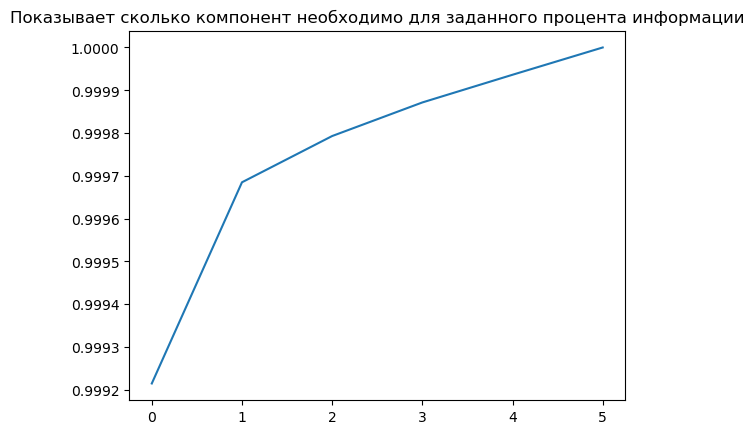

Реконструкция данных



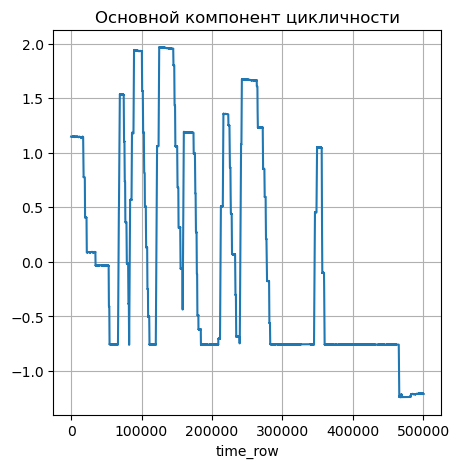

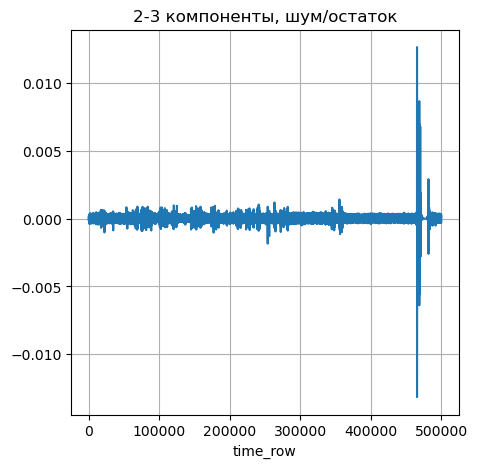

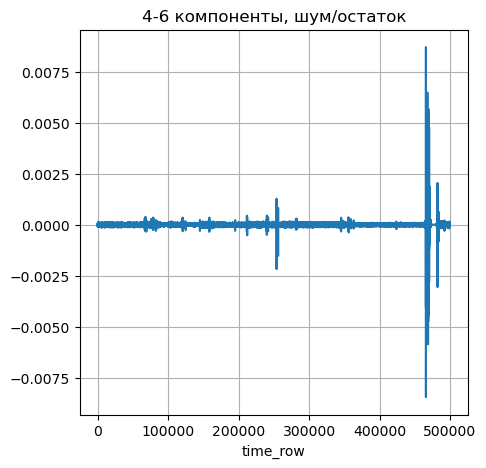

In [14]:
research_signs(df['column1'], 6)

#### 2.2.1.5 Вывод

Был исследован через SSA признак column1, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F6. Этот компонент объясняет 99% изменений временного ряда признака column1.

#### 2.1.1.6 Параметры признака column1 при L=12

Разложение на компоненты признака column1



,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
time_row,,,,,,,,,,,,
0,1.146459,0.000182,-0.000091,-0.000062,0.000087,0.000046,-3.670813e-05,-0.000022,0.000005,-2.874061e-06,-1.631509e-05,9.188120e-06
1,1.146447,0.000175,-0.000066,-0.000068,-0.000005,0.000021,3.881786e-05,0.000017,-0.000011,3.323906e-06,1.503265e-05,-2.047035e-05
2,1.146439,0.000156,-0.000021,-0.000041,-0.000051,-0.000042,1.077278e-05,0.000006,0.000017,-7.543956e-07,3.680852e-06,2.840623e-05
3,1.146433,0.000132,0.000031,0.000010,-0.000030,-0.000044,-3.466443e-05,-0.000020,-0.000016,-1.029931e-06,-2.140851e-05,-2.684330e-05
4,1.146431,0.000108,0.000073,0.000057,0.000031,0.000021,-3.756308e-06,0.000010,0.000010,-2.499882e-06,1.890431e-05,1.523455e-05
...,...,...,...,...,...,...,...,...,...,...,...,...
499994,-1.210361,-0.000209,-0.000034,-0.000007,0.000016,-0.000050,-5.749034e-05,0.000016,0.000014,8.862425e-07,1.101947e-05,-2.079628e-06
499995,-1.210388,-0.000239,-0.000013,0.000003,-0.000072,-0.000086,7.623948e-07,0.000008,-0.000015,-2.097950e-07,-1.254580e-05,-5.555134e-07
499996,-1.210408,-0.000258,0.000022,0.000014,-0.000083,0.000014,5.626300e-05,-0.000013,0.000011,-2.063159e-06,-3.915644e-07,2.334289e-06


,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
count,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05
mean,8.565185e-10,-1.050513e-09,3.824055e-11,-1.132406e-10,2.957664e-10,7.685671e-11,-8.243156e-11,-6.642693e-12,2.412425e-12,-1.262516e-12,-1.958858e-11,3.885484e-12
std,1.000000e+00,1.045824e-04,7.110357e-05,6.312163e-05,4.310274e-05,3.484962e-05,3.029367e-05,2.347758e-05,2.812325e-05,2.056444e-05,2.594206e-05,2.484504e-05
min,-1.239700e+00,-8.369757e-03,-5.482774e-03,-3.981806e-03,-3.183281e-03,-2.602090e-03,-1.935027e-03,-1.916254e-03,-2.570042e-03,-2.178309e-03,-2.031982e-03,-2.558174e-03
25%,-7.585199e-01,-3.823880e-05,-3.573906e-05,-2.987938e-05,-2.080109e-05,-1.495496e-05,-9.170577e-06,-5.114738e-06,-6.075156e-06,-4.663352e-06,-4.698373e-06,-5.963046e-06
50%,-7.050720e-01,-3.362304e-13,-1.316153e-13,-5.512647e-18,-2.855836e-14,-7.926830e-19,-2.883163e-15,-2.886791e-19,-1.175369e-17,-2.868402e-20,-1.888783e-16,-1.867246e-20
75%,1.049404e+00,3.775775e-05,3.552096e-05,2.985920e-05,2.070218e-05,1.493115e-05,9.179115e-06,5.126105e-06,6.072656e-06,4.673747e-06,4.712860e-06,5.961906e-06
max,1.967493e+00,6.280489e-03,5.346592e-03,4.105898e-03,3.147181e-03,2.550772e-03,2.119560e-03,2.376115e-03,2.716935e-03,2.175076e-03,1.741214e-03,2.537707e-03


Строим графики для разложенных компонентов признака column1



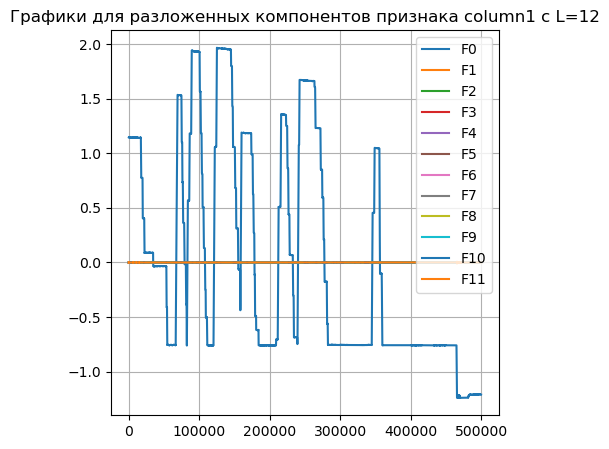

Проверка размера данных при L для контроля column1



(499999, 12)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column1



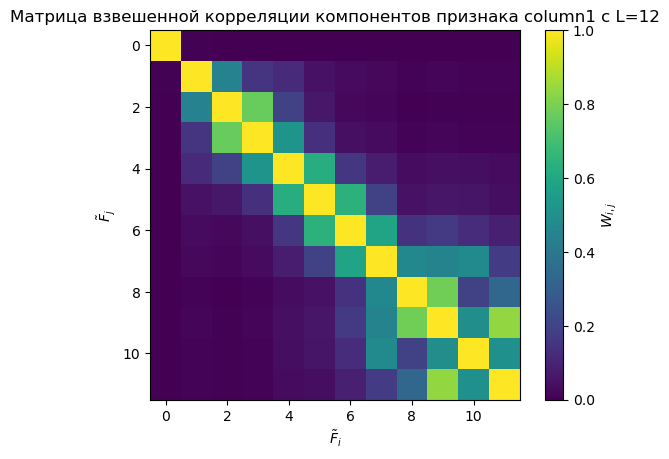

Ранжируем компоненты по убыванию важности признака column1

Визуализация первых 12 компонент признака column1



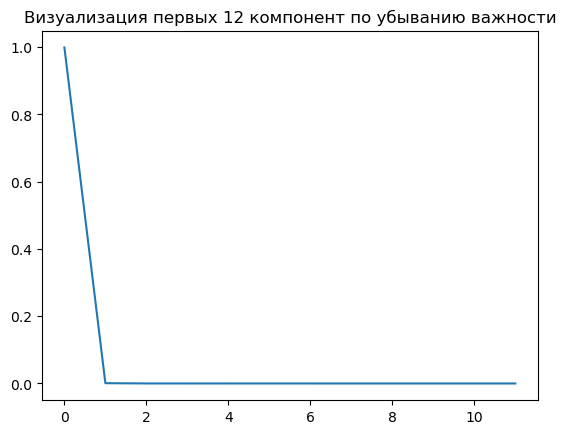

Показывает какое количество компонент объясняет основной процент информации



0.9984468553225422

0.00011883578566813866

0.00024074293331342148

0.0001323826087537011

Показывает сколько компонент необходимо для заданного процента информации



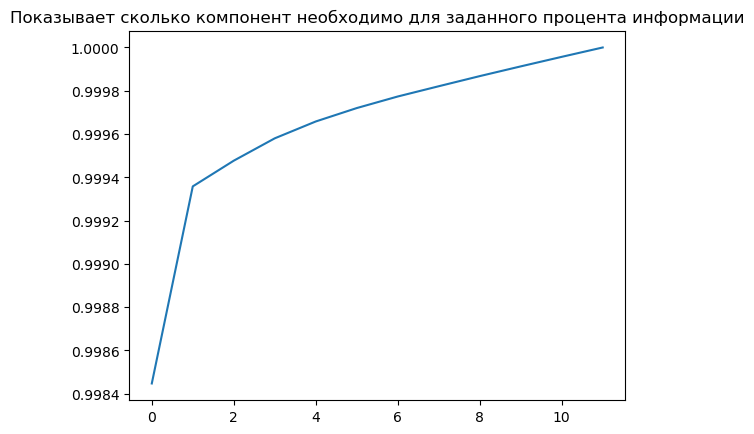

Реконструкция данных



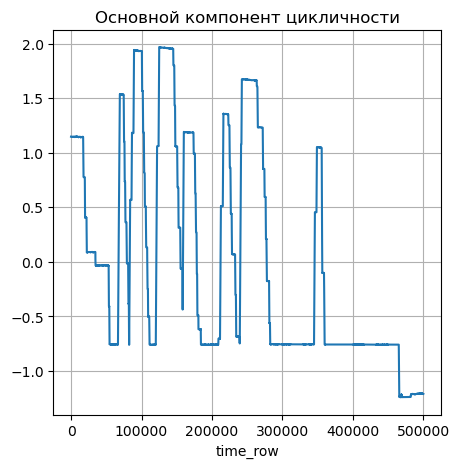

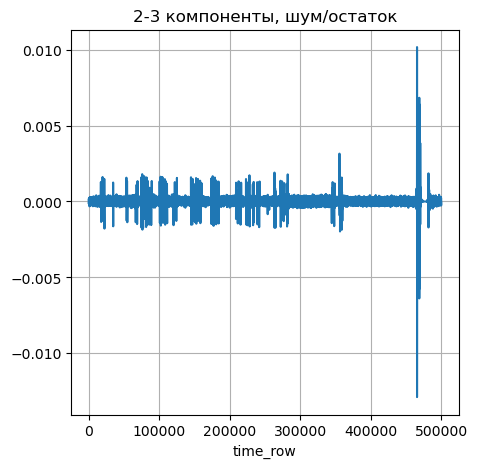

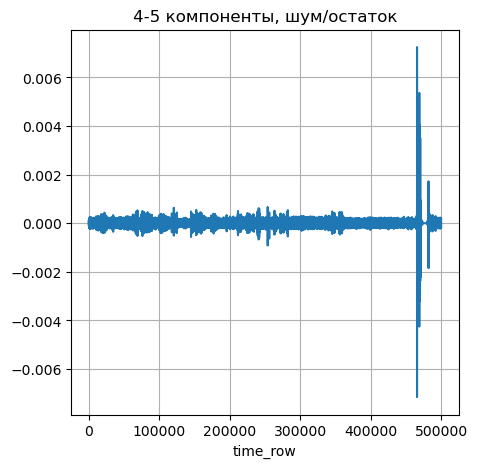

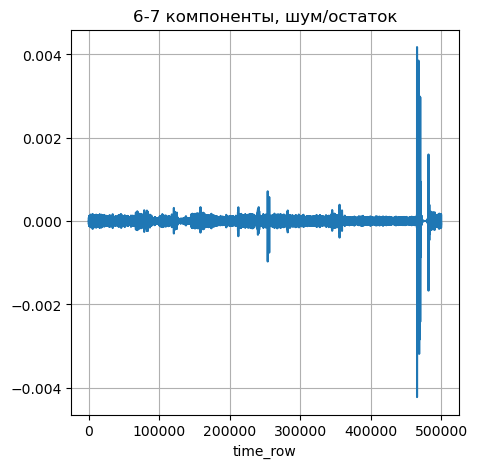

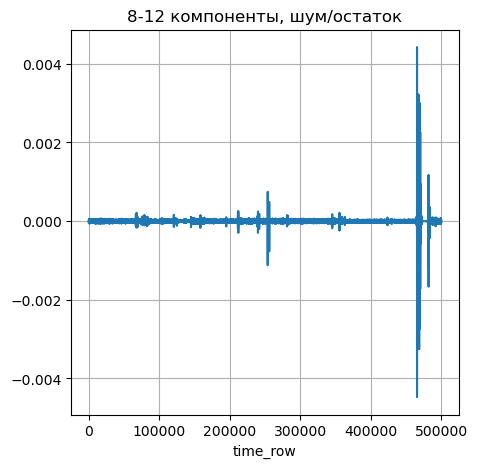

In [15]:
research_signs(df['column1'], 12)

#### 2.1.1.7 Вывод

Был исследован через SSA признак column1, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F12. Этот компонент объясняет 99% изменений временного ряда признака column1.

### 2.2.2 Исследуем второй признак(column2)

#### 2.2.2.1 Обзор второго признака

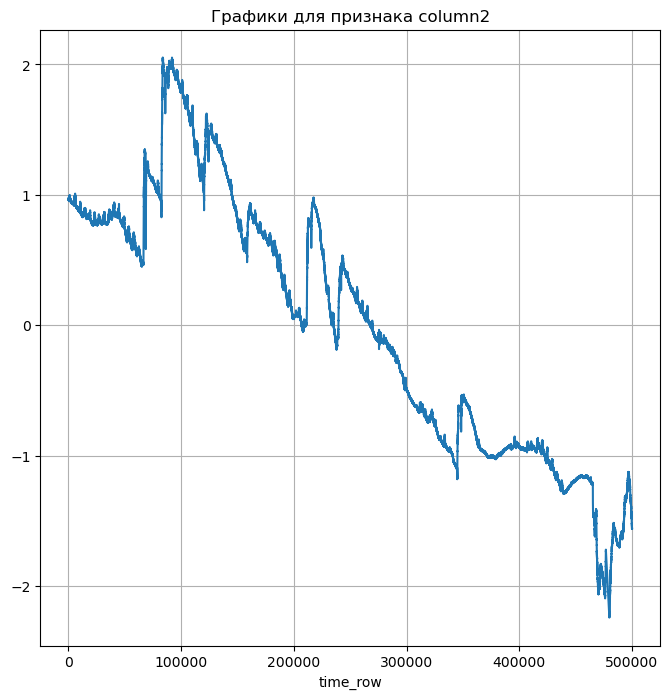

In [16]:
# Строим график для первого признака
df['column2'].plot(grid=True, figsize=(8,8))
plt.title('Графики для признака column2')
plt.show()

#### 2.2.2.2 Параметры признака column2 при L=3

Разложение на компоненты признака column2



,F0,F1,F2
time_row,,,
0,0.970374,-0.000648,0.000318
1,0.970209,0.000174,-0.000643
2,0.970574,-0.000146,0.000916
3,0.970715,-0.000247,-0.001423
4,0.970975,0.001096,0.001449
...,...,...,...
499994,-1.559589,-0.000679,0.000473
499995,-1.559406,0.000628,-0.000452
499996,-1.559074,0.000636,0.000863


,F0,F1,F2
count,4.999990e+05,4.999990e+05,4.999990e+05
mean,1.803343e-09,-2.059579e-09,2.562360e-10
std,9.999994e-01,8.231022e-04,8.771879e-04
min,-2.240961e+00,-3.350268e-02,-3.430344e-02
25%,-9.430028e-01,-5.252123e-04,-5.583003e-04
50%,6.522003e-02,-1.756715e-12,-1.409986e-14
75%,8.172579e-01,5.276495e-04,5.589513e-04
max,2.050626e+00,1.948915e-02,2.355522e-02


Строим графики для разложенных компонентов признака column2



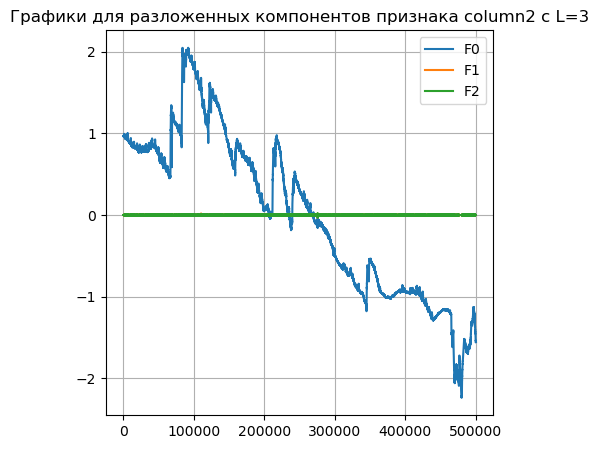

Проверка размера данных при L для контроля column2



(499999, 3)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column2



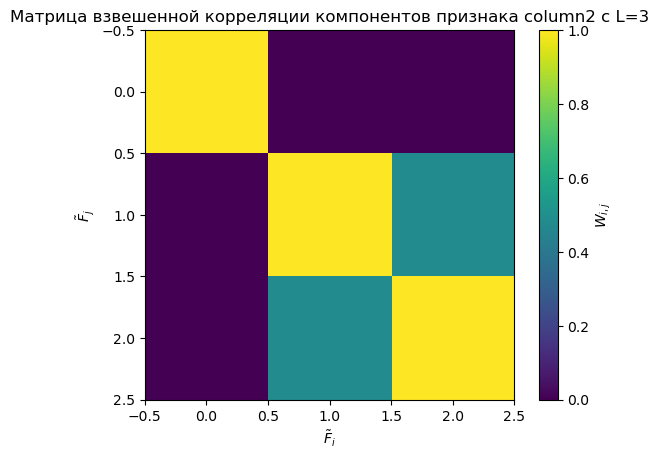

Ранжируем компоненты по убыванию важности признака column2

Визуализация первых 3х компонент признака column2



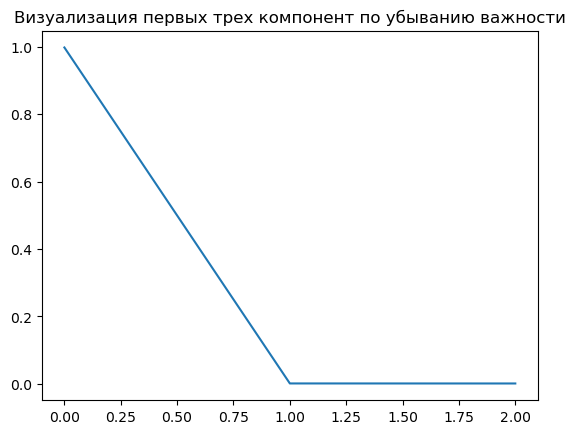

Показывает какое количество компонент объясняет основной процент информации



0.9976954923147119

0.0010985201949968292

Показывает сколько компонент необходимо для заданного процента информации



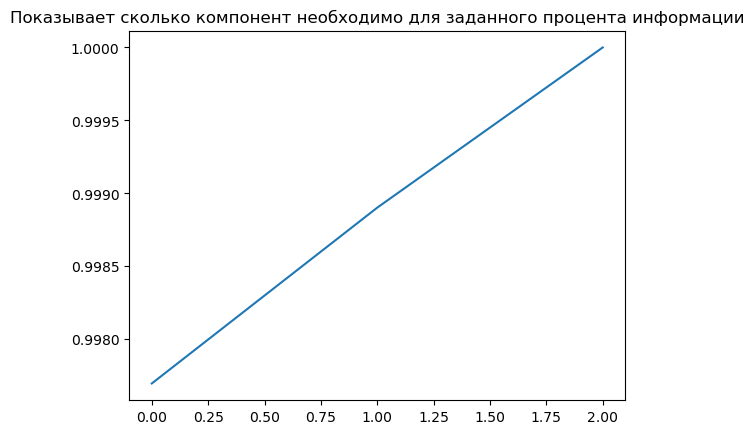

Реконструкция данных



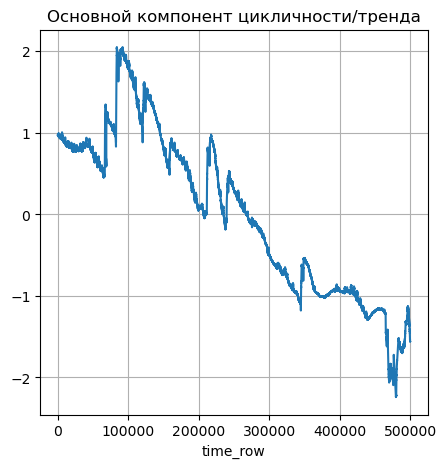

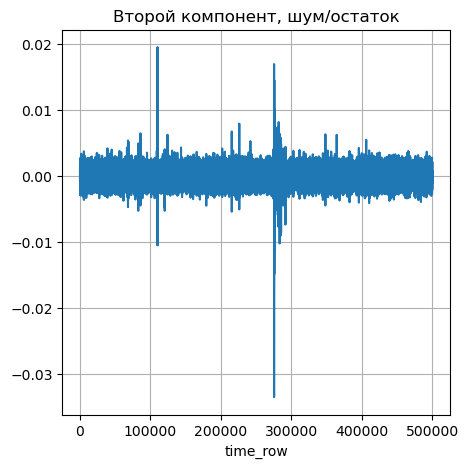

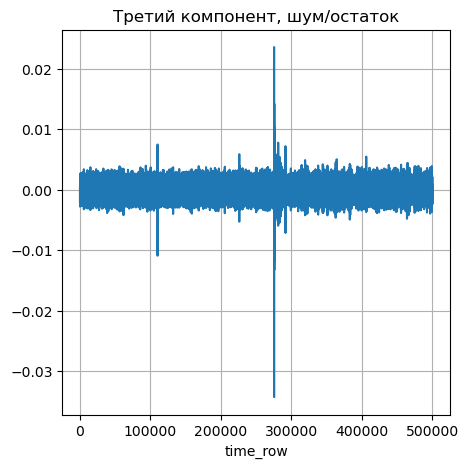

In [17]:
research_signs(df['column2'], 3)

#### 2.2.2.3 Вывод

Был исследован через SSA признак column2, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F2. Этот компонент объясняет 99% изменений временного ряда признака column2.

#### 2.2.2.4 Параметры признака column2 при L=6

Разложение на компоненты признака column2



,F0,F1,F2,F3,F4,F5
time_row,,,,,,
0,0.970583,-0.000605,-0.000062,0.000210,-0.000587,0.000505
1,0.970507,-0.000130,-0.000440,0.000219,0.000460,-0.000877
2,0.970537,0.000151,-0.000133,-0.000467,0.000199,0.001057
3,0.970426,0.000371,0.000179,-0.000099,-0.000798,-0.001033
4,0.970394,0.000498,0.000436,0.000505,0.000873,0.000814
...,...,...,...,...,...,...
499994,-1.559393,-0.000177,-0.000631,-0.000370,0.000256,0.000521
499995,-1.559351,-0.000181,0.000239,0.000741,-0.000039,-0.000641
499996,-1.559330,-0.000032,0.000875,0.000232,0.000031,0.000649


,F0,F1,F2,F3,F4,F5
count,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05
mean,2.631299e-11,6.056020e-10,-1.325069e-09,3.474630e-10,-1.504198e-10,4.961112e-10
std,9.999988e-01,6.182288e-04,5.251059e-04,5.006039e-04,5.066870e-04,6.031465e-04
min,-2.239263e+00,-1.853065e-02,-1.602069e-02,-1.723962e-02,-1.679737e-02,-1.739853e-02
25%,-9.430153e-01,-3.630232e-04,-3.339567e-04,-3.229055e-04,-3.268019e-04,-3.874910e-04
50%,6.515967e-02,-1.131696e-11,-7.246237e-14,-9.448723e-14,-6.331013e-15,-8.411719e-15
75%,8.173641e-01,3.647844e-04,3.343256e-04,3.232855e-04,3.271785e-04,3.870453e-04
max,2.049861e+00,1.722145e-02,1.238160e-02,1.226490e-02,1.054367e-02,1.568265e-02


Строим графики для разложенных компонентов признака column2



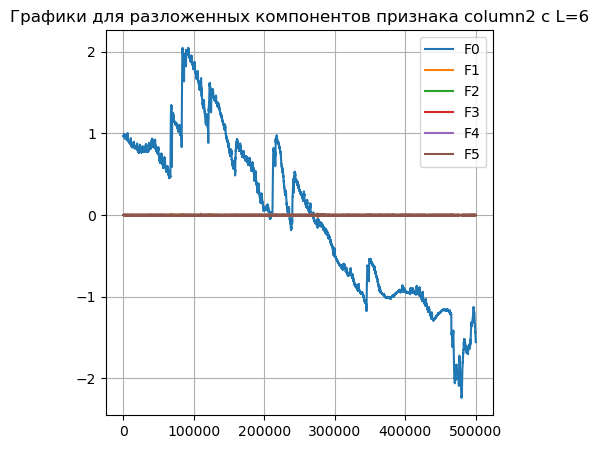

Проверка размера данных при L для контроля column2



(499999, 6)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column2



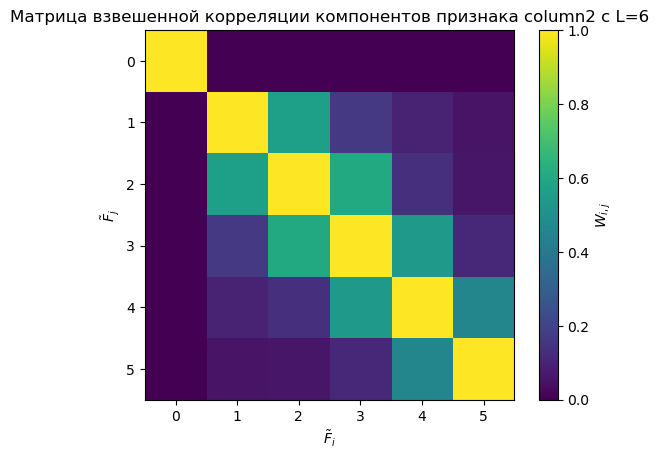

Ранжируем компоненты по убыванию важности признака column2

Визуализация первых 6 компонент признака column2



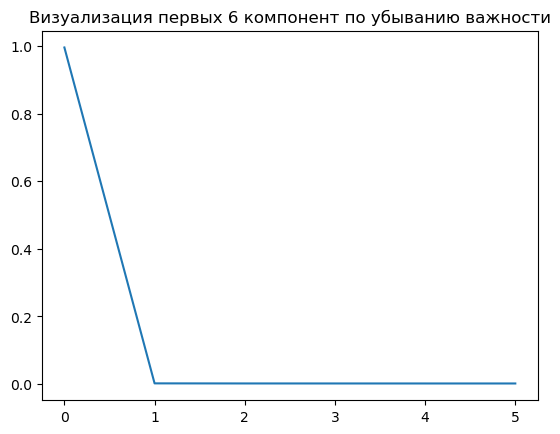

Показывает какое количество компонент объясняет основной процент информации



0.99572227288146

0.00084796516579042

0.0015409572226361451

Показывает сколько компонент необходимо для заданного процента информации



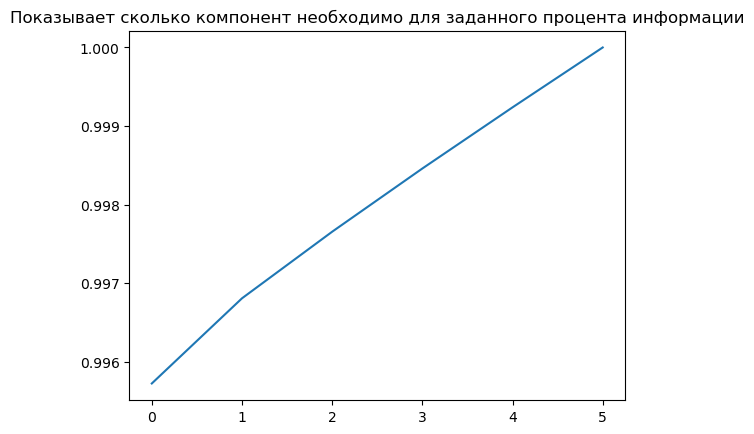

Реконструкция данных



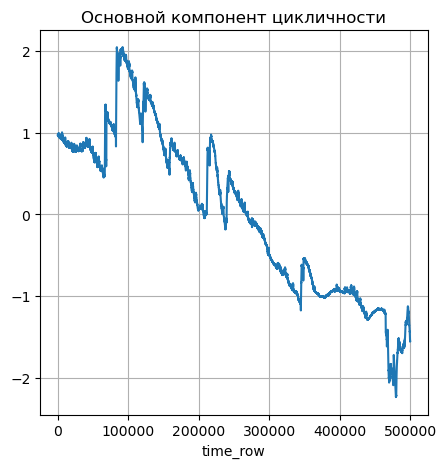

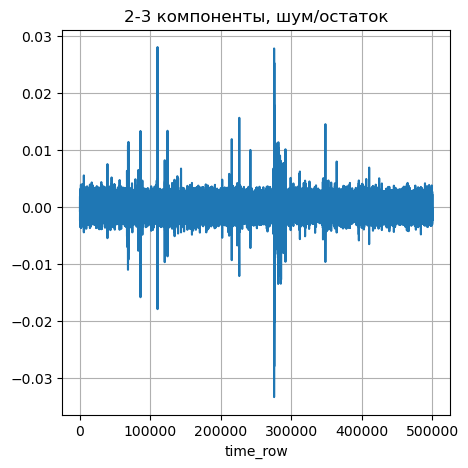

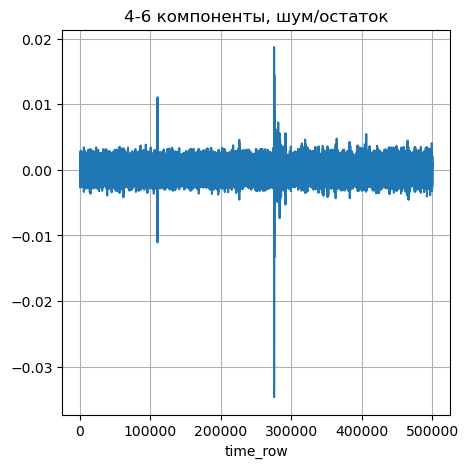

In [18]:
research_signs(df['column2'], 6)

#### 2.2.2.5 Вывод

Был исследован через SSA признак column2, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F5. Этот компонент объясняет 99% изменений временного ряда признака column2.

#### 2.2.2.6 Параметры признака column2 при L=12

Разложение на компоненты признака column2



,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
time_row,,,,,,,,,,,,
0,0.969644,0.001384,-0.000912,-0.000165,-0.000204,0.000212,0.000302,-0.000368,-0.000202,-0.000212,0.000548,0.000015
1,0.969555,0.001451,-0.000610,-0.000230,-0.000070,-0.000237,0.000093,0.000350,0.000225,0.000137,-0.000924,-0.000001
2,0.969566,0.001273,-0.000039,-0.000294,0.000218,-0.000280,-0.000269,-0.000031,0.000003,0.000121,0.001123,-0.000049
3,0.969520,0.001049,0.000346,-0.000155,0.000154,0.000218,-0.000200,-0.000218,-0.000307,-0.000334,-0.001156,0.000128
4,0.969567,0.000709,0.000726,0.000050,0.000014,0.000360,0.000380,0.000129,0.000442,0.000358,0.001017,-0.000232
...,...,...,...,...,...,...,...,...,...,...,...,...
499994,-1.559788,0.000398,0.000171,-0.000318,-0.000371,-0.000544,-0.000094,-0.000216,0.000284,0.000243,0.000461,-0.000019
499995,-1.559786,0.000610,-0.000066,-0.000245,-0.000122,0.000347,0.000374,0.000480,0.000037,-0.000287,-0.000552,-0.000019
499996,-1.559705,0.000643,-0.000164,-0.000100,0.000365,0.000673,0.000161,-0.000100,-0.000175,0.000203,0.000581,0.000043


,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
count,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05
mean,-1.105313e-08,1.289449e-08,-1.551338e-09,-9.843802e-11,8.160804e-11,-9.272109e-10,2.788871e-10,1.527219e-10,-5.042760e-11,-1.733757e-10,4.519542e-10,-5.743250e-12
std,9.999978e-01,6.281973e-04,4.254413e-04,3.757270e-04,3.578265e-04,3.479965e-04,3.434157e-04,3.370925e-04,3.326846e-04,3.354012e-04,3.471206e-04,4.224333e-04
min,-2.238109e+00,-3.192964e-02,-1.377988e-02,-9.166158e-03,-7.081185e-03,-8.748100e-03,-9.182295e-03,-8.360535e-03,-8.211017e-03,-8.491423e-03,-8.565125e-03,-8.888056e-03
25%,-9.430056e-01,-2.850930e-04,-2.447540e-04,-2.317694e-04,-2.277318e-04,-2.242647e-04,-2.228533e-04,-2.184536e-04,-2.156844e-04,-2.175514e-04,-2.250984e-04,-2.721948e-04
50%,6.510315e-02,-4.966845e-11,-4.923272e-13,-2.395709e-13,-2.844813e-14,-3.212899e-14,-5.989725e-15,-1.011663e-14,-3.028768e-15,-3.603578e-15,-6.391439e-16,-4.628819e-16
75%,8.173929e-01,2.842794e-04,2.439450e-04,2.317708e-04,2.275621e-04,2.243749e-04,2.231824e-04,2.187802e-04,2.155806e-04,2.168641e-04,2.249557e-04,2.720545e-04
max,2.048714e+00,2.329435e-02,1.106968e-02,8.257791e-03,7.431032e-03,7.792344e-03,8.099586e-03,5.907678e-03,5.205548e-03,6.546682e-03,7.601316e-03,8.657902e-03


Строим графики для разложенных компонентов признака column2



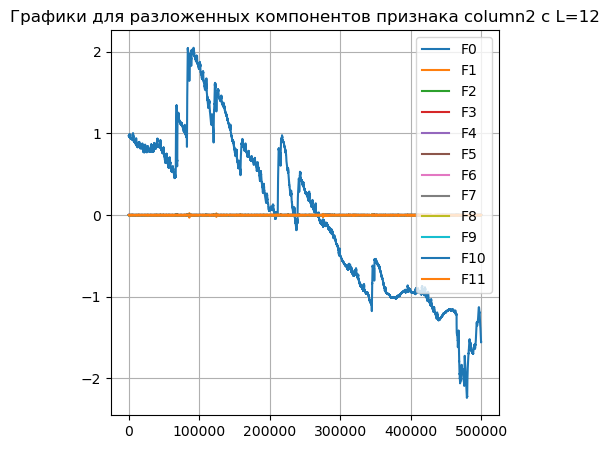

Проверка размера данных при L для контроля column2



(499999, 12)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column2



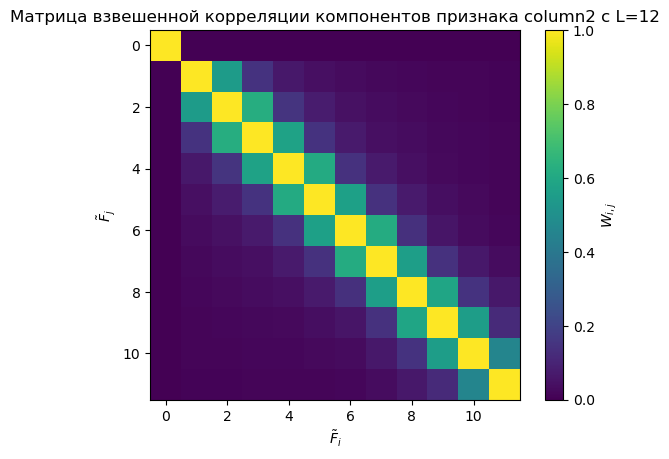

Ранжируем компоненты по убыванию важности признака column2

Визуализация первых 12 компонент признака column2



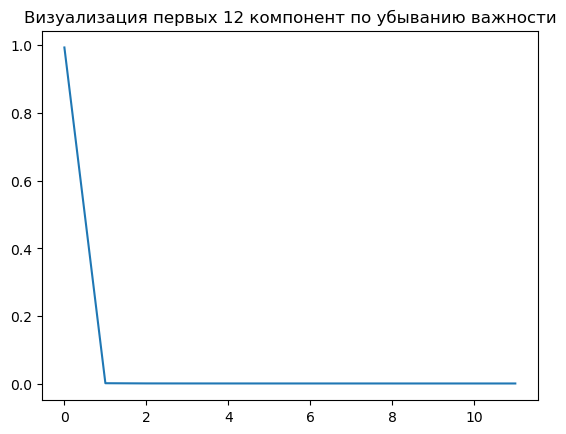

Показывает какое количество компонент объясняет основной процент информации



0.9928681997833074

0.000727852032019606

0.0023093636989693672

0.0016156276018898415

Показывает сколько компонент необходимо для заданного процента информации



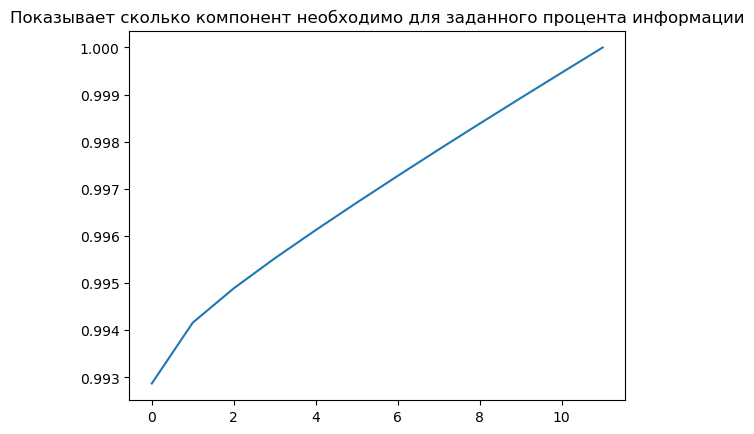

Реконструкция данных



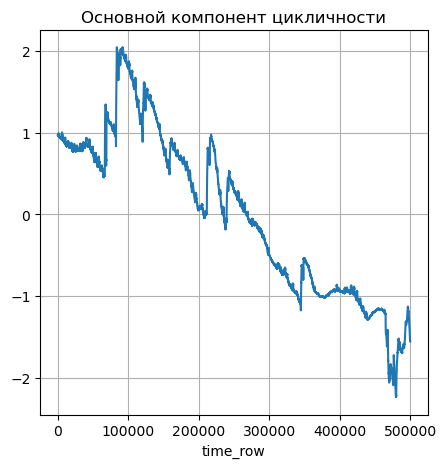

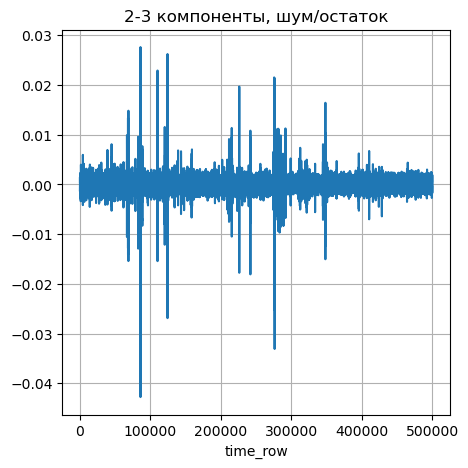

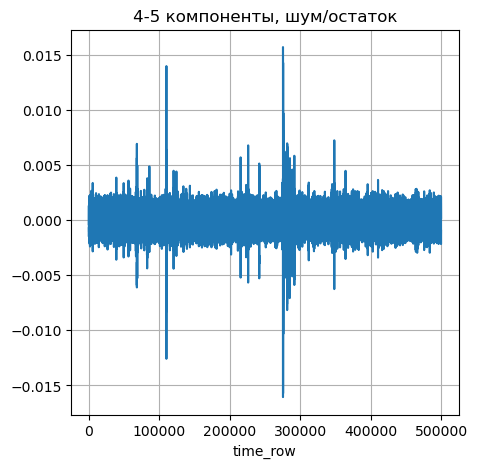

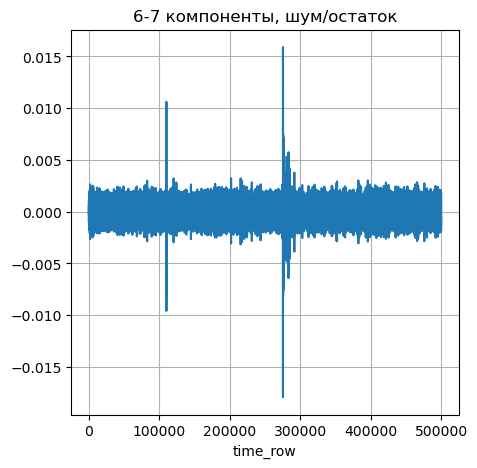

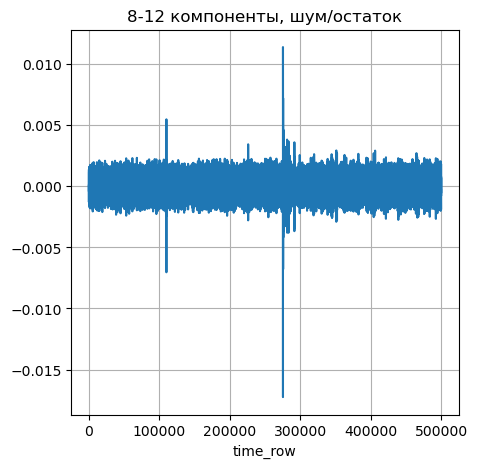

In [19]:
research_signs(df['column2'], 12)

#### 2.2.2.7 Вывод

Был исследован через SSA признак column2, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F11. Этот компонент объясняет 99% изменений временного ряда признака column2.

### 2.2.3 Исследуем третий признак(column3)

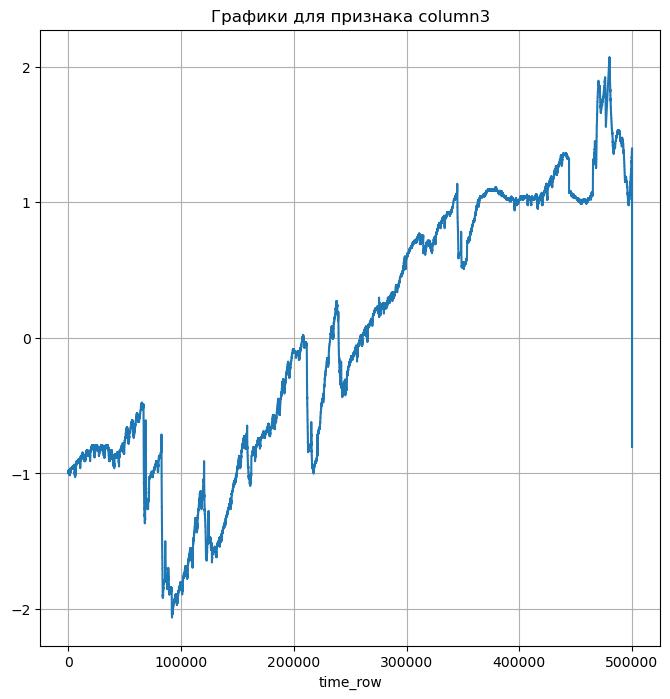

In [20]:
# Строим график для третьего признака
df['column3'].plot(grid=True, figsize=(8,8))
plt.title('Графики для признака column3')
plt.show()

#### 2.2.3.1 Параметры признака column3 при L=3

Разложение на компоненты признака column3



,F0,F1,F2
time_row,,,
0,-0.993370,0.004285,0.000086
1,-0.995557,0.002225,-0.000038
2,-0.996770,-0.001455,0.000484
3,-0.998227,-0.002912,-0.000973
4,-0.996770,-0.001455,0.000484
...,...,...,...
499994,1.316093,0.122222,-0.040626
499995,1.071305,0.244616,0.081768
499996,0.581728,0.122222,-0.040626


,F0,F1,F2
count,499999.000000,4.999990e+05,4.999990e+05
mean,0.000001,-1.229219e-06,1.255885e-08
std,0.999997,1.527721e-03,5.403180e-04
min,-2.063835,-7.473526e-01,-4.062612e-02
25%,-0.844749,-3.945151e-13,-8.840125e-13
50%,-0.018587,3.130693e-15,7.015123e-15
75%,1.015450,4.276445e-13,9.582473e-13
max,2.066487,2.446165e-01,8.176816e-02


Строим графики для разложенных компонентов признака column3



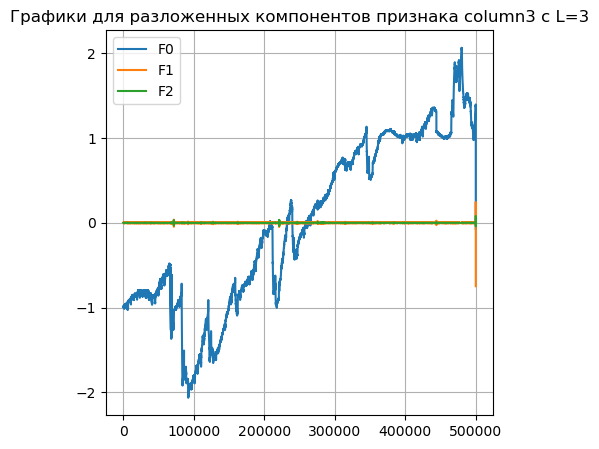

Проверка размера данных при L для контроля column3



(499999, 3)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column3



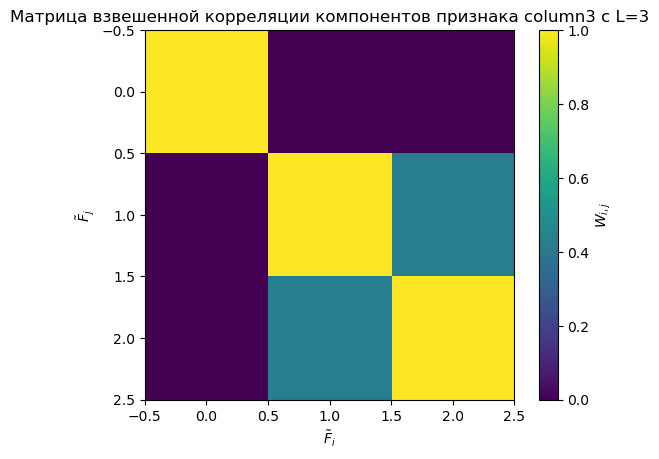

Ранжируем компоненты по убыванию важности признака column3

Визуализация первых 3х компонент признака column3



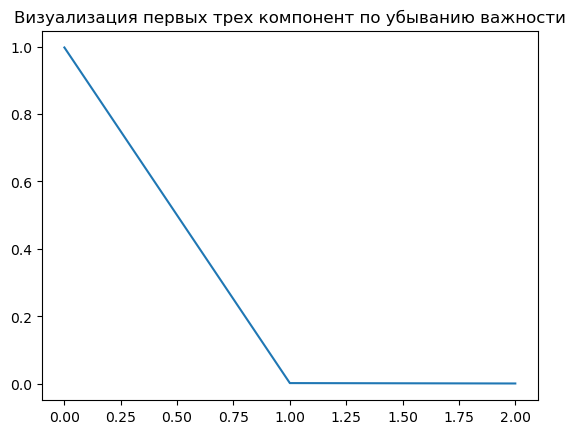

Показывает какое количество компонент объясняет основной процент информации



0.99723021780368

0.0008108378975310192

Показывает сколько компонент необходимо для заданного процента информации



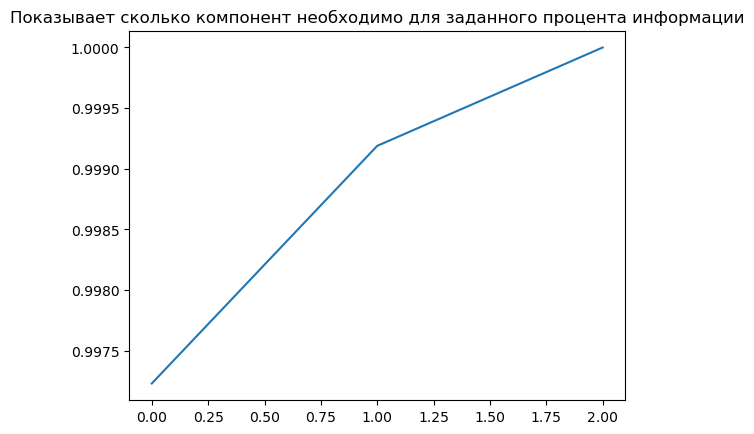

Реконструкция данных



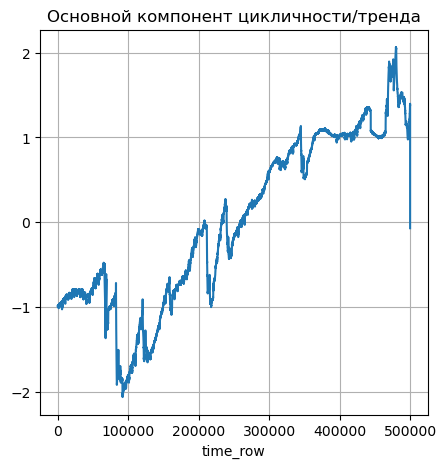

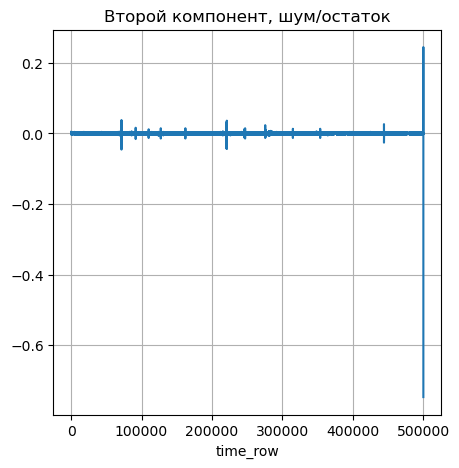

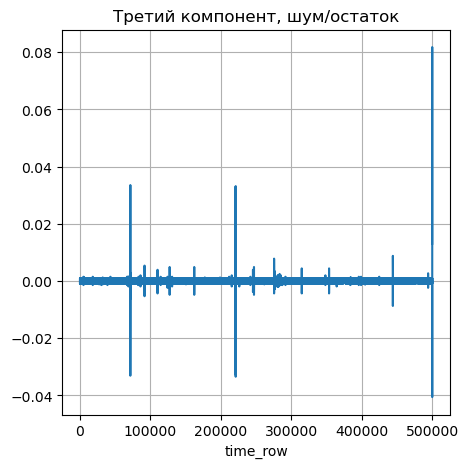

In [21]:
research_signs(df['column3'], 3)

#### 2.2.3.2 Вывод

Был исследован через SSA признак column3, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F2. Этот компонент объясняет 99% изменений временного ряда признака column3.

#### 2.1.3.3 Параметры признака column3 при L=6

Разложение на компоненты признака column3



,F0,F1,F2,F3,F4,F5
time_row,,,,,,
0,-0.995554,0.001389,0.005447,-0.000396,-0.000207,0.000322
1,-0.995555,-0.000842,0.002533,0.000708,0.000178,-0.000391
2,-0.995314,-0.002289,-0.001123,0.000365,0.000124,0.000496
3,-0.994829,-0.002710,-0.002949,-0.000778,-0.000269,-0.000578
4,-0.994100,-0.002058,-0.001809,-0.000360,0.000099,0.000486
...,...,...,...,...,...,...
499994,1.152902,0.218143,0.071007,-0.001923,-0.012718,-0.029721
499995,1.091704,0.059164,0.118368,0.061062,0.031701,0.035690
499996,0.989708,-0.297984,0.041803,-0.012895,-0.022108,-0.035200


,F0,F1,F2,F3,F4,F5
count,499999.000000,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05
mean,0.000004,-3.477507e-06,-2.173393e-07,2.747022e-09,5.437623e-09,-2.062692e-08
std,0.999996,2.588629e-03,7.276559e-04,4.420040e-04,4.523887e-04,2.449428e-04
min,-2.060920,-1.329156e+00,-1.511663e-01,-5.654027e-02,-3.291923e-02,-3.520044e-02
25%,-0.844749,-2.069247e-12,-7.503680e-12,-2.223543e-14,-7.727123e-14,-6.752631e-15
50%,-0.018587,9.834891e-14,3.566412e-13,1.056824e-15,3.672612e-15,3.209447e-16
75%,1.014115,1.858179e-12,6.738288e-12,1.996736e-14,6.938940e-14,6.063848e-15
max,2.066487,2.558795e-01,1.183681e-01,6.106188e-02,3.290330e-02,3.568977e-02


Строим графики для разложенных компонентов признака column3



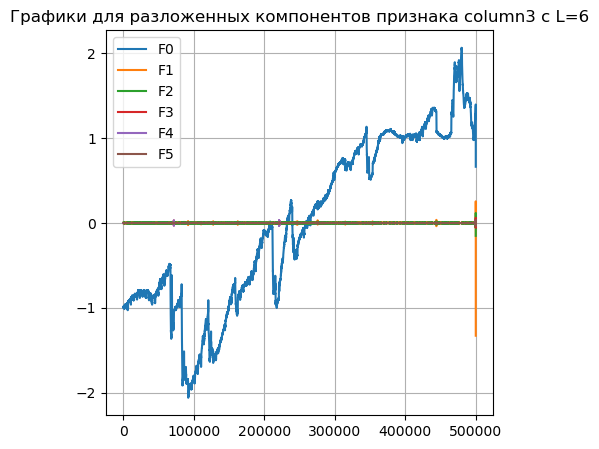

Проверка размера данных при L для контроля column3



(499999, 6)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column3



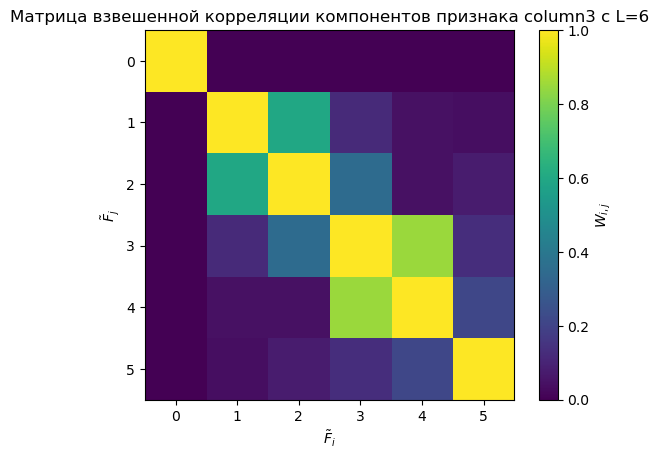

Ранжируем компоненты по убыванию важности признака column3

Визуализация первых 6 компонент признака column3



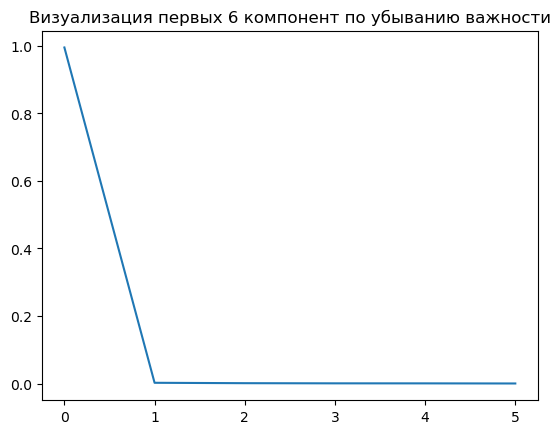

Показывает какое количество компонент объясняет основной процент информации



0.9946444194042677

0.001214886991221729

0.0010110175836746183

Показывает сколько компонент необходимо для заданного процента информации



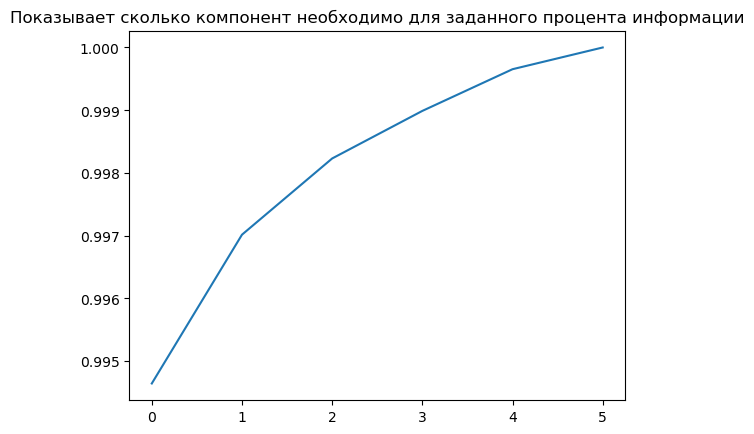

Реконструкция данных



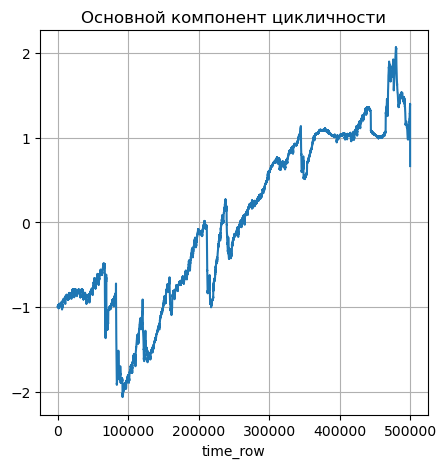

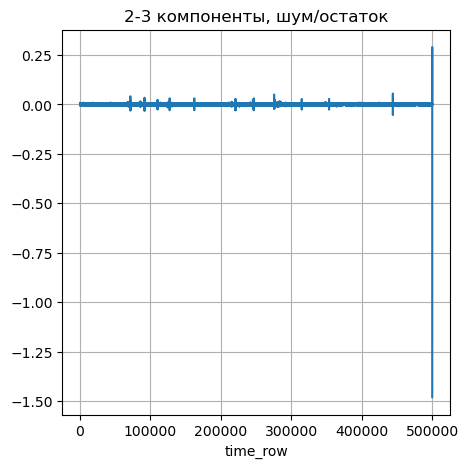

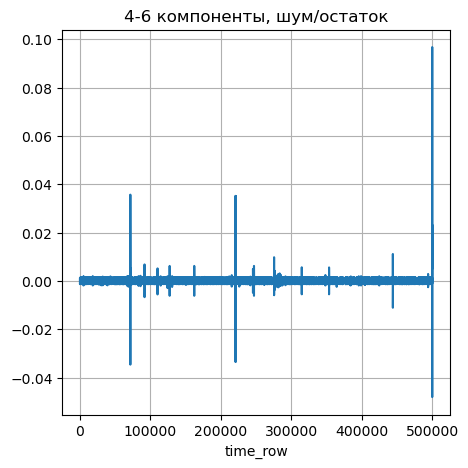

In [22]:
research_signs(df['column3'], 6)

#### 2.2.3.4 Вывод

Был исследован через SSA признак column3, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F5. Этот компонент объясняет 99% изменений временного ряда признака column3.

#### 2.2.3.5 Параметры признака column3 при L=12

Разложение на компоненты признака column3



,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
time_row,,,,,,,,,,,,
0,-0.992271,-0.003053,-0.000371,0.003436,0.003143,0.000151,-0.000055,3.398672e-04,-0.000390,0.000011,-0.000068,0.000128
1,-0.992272,-0.003371,-0.001305,0.001302,0.001395,0.000528,0.000049,2.464805e-04,0.000353,-0.000119,0.000067,-0.000243
2,-0.992152,-0.003369,-0.001823,-0.000692,-0.000661,0.000021,0.000063,-1.368216e-08,0.000266,0.000277,-0.000003,0.000333
3,-0.991910,-0.003070,-0.001794,-0.001631,-0.001642,-0.000554,-0.000120,-3.285212e-04,-0.000354,-0.000274,-0.000070,-0.000365
4,-0.991547,-0.002472,-0.001233,-0.001453,-0.000990,-0.000188,0.000046,-2.069398e-04,-0.000250,0.000111,0.000107,0.000333
...,...,...,...,...,...,...,...,...,...,...,...,...
499994,1.275297,-0.101079,0.134474,0.089197,0.034172,0.001996,-0.006290,5.181529e-04,0.001503,-0.014489,-0.006179,-0.011429
499995,1.244697,-0.218349,0.063722,0.094063,0.066687,0.040406,0.015814,1.679510e-02,0.025239,0.028951,0.005035,0.014630
499996,1.193698,-0.416049,-0.092699,0.018845,0.026019,-0.007619,-0.011417,2.050363e-03,-0.004868,-0.028304,-0.002155,-0.014177


,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
count,499999.000000,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05,4.999990e+05
mean,0.000006,-3.874661e-06,-1.046184e-06,-4.197692e-07,-1.482509e-07,-6.548364e-09,3.674208e-10,-3.409078e-08,-1.484402e-09,-5.543733e-09,8.184710e-10,-1.789469e-09
std,0.999995,2.220787e-03,1.300891e-03,8.182340e-04,5.209964e-04,3.519126e-04,4.200569e-04,1.813185e-04,1.816607e-04,1.171434e-04,1.143194e-04,1.079503e-04
min,-2.059372,-9.873126e-01,-5.056139e-01,-2.366226e-01,-1.034414e-01,-3.809743e-02,-3.275798e-02,-2.369122e-02,-2.534480e-02,-2.830351e-02,-6.179286e-03,-1.417714e-02
25%,-0.844749,-1.343001e-12,-1.983726e-11,-2.562992e-13,-3.553235e-12,-1.411841e-14,-4.897663e-14,-1.952248e-14,-3.007514e-13,-1.191871e-15,-5.975095e-16,-1.103981e-14
50%,-0.018587,9.144700e-14,1.537754e-12,1.745180e-14,2.754414e-13,1.059000e-15,3.721866e-15,1.329315e-15,2.047862e-14,8.168190e-17,4.068533e-17,8.389447e-16
75%,1.014145,1.271683e-12,2.062743e-11,2.451023e-13,3.699848e-12,1.392006e-14,4.950131e-14,1.904135e-14,2.927381e-13,1.319890e-15,7.476483e-16,1.116505e-14
max,2.066486,9.650911e-02,1.474433e-01,9.406279e-02,6.668686e-02,4.040631e-02,3.274677e-02,1.679510e-02,2.523908e-02,2.895091e-02,5.369886e-03,1.462995e-02


Строим графики для разложенных компонентов признака column3



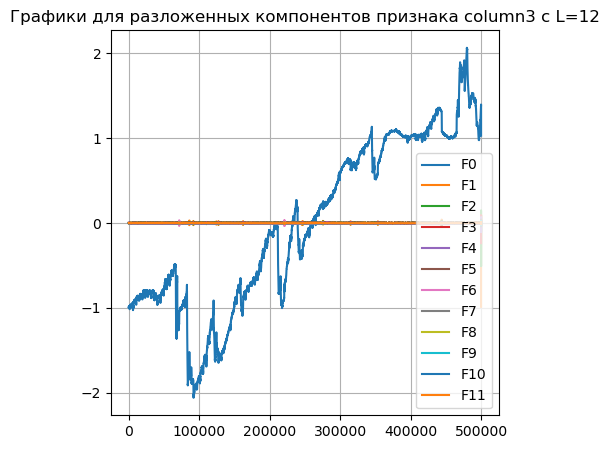

Проверка размера данных при L для контроля column3



(499999, 12)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака column3



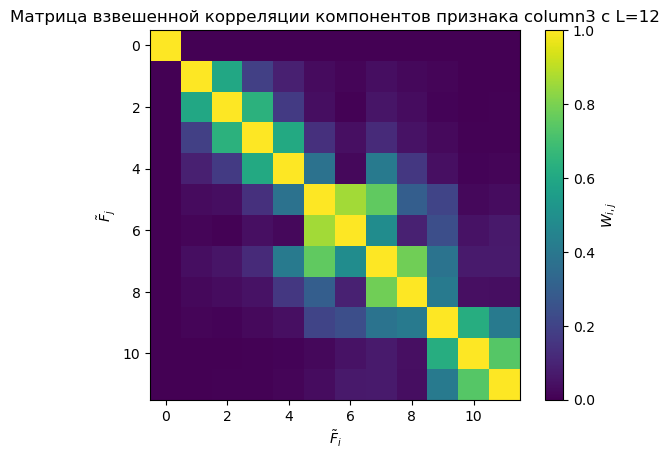

Ранжируем компоненты по убыванию важности признака column3

Визуализация первых 12 компонент признака column3



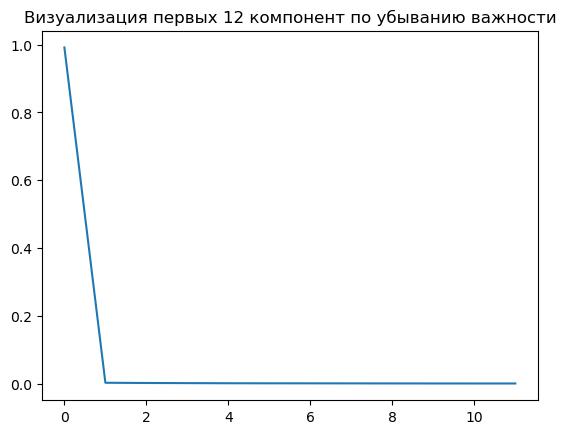

Показывает какое количество компонент объясняет основной процент информации



0.9912981214522857

0.0016271667255204256

0.002597304650554279

0.0006113537692339089

Показывает сколько компонент необходимо для заданного процента информации



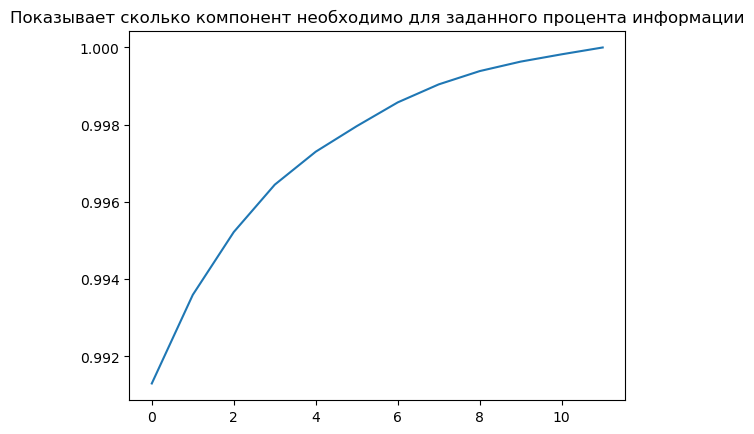

Реконструкция данных



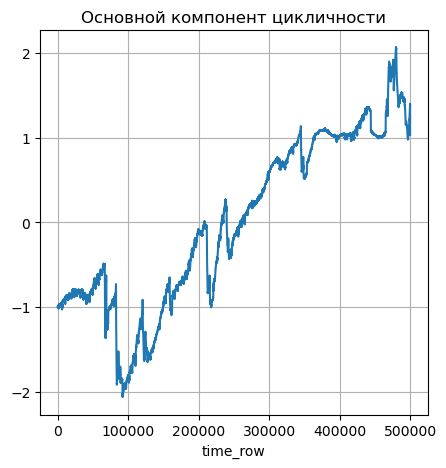

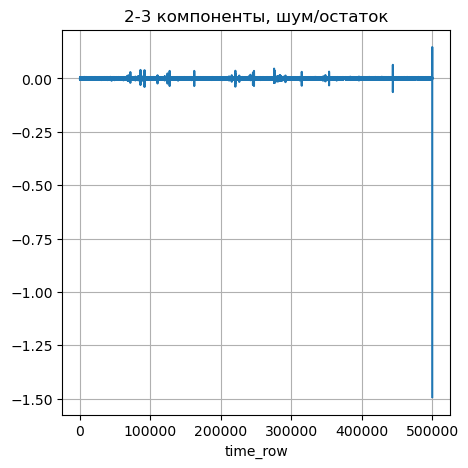

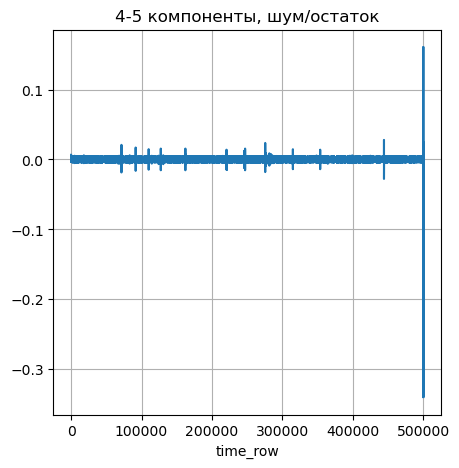

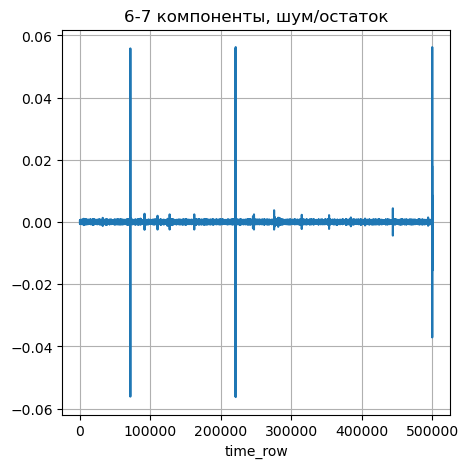

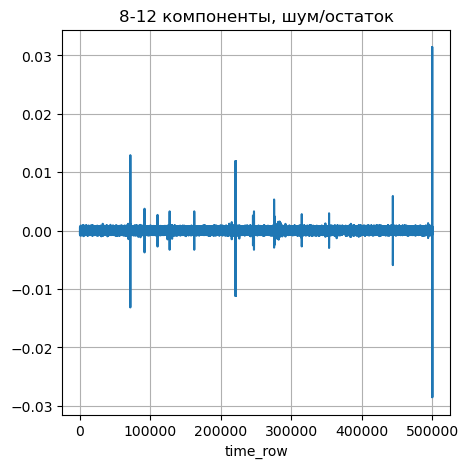

In [23]:
research_signs(df['column3'], 12)

#### 2.2.3.6 Вывод

Был исследован через SSA признак column3, из него был выделен основной компонент цикличности/тренда - признак F0 и отделены шум/остатки - признаки F1-F11. Этот компонент объясняет 99% изменений временного ряда признака column3.

## 2.3 Исследование компонентов

Здесь по примеру из https://habr.com/ru/companies/mvideo/articles/769190/ применю ряд проверок, чтобы разобраться в свойствах каждого из компонентов каждого основного компонента признака.

Проанализируем каждый основной компонент путем следующих проверок:
1. Проверка на стационарность. Стационарный ряд — это ряд, в котором статистические характеристики, такие как среднее и дисперсия, остаются постоянными во времени. Критерий - тест Дики-Фуллера,
2. Автокорреляционный анализ(https://apxml.com/courses/time-series-analysis-forecasting/chapter-3-autocorrelation-model-id/interpreting-acf-pacf,https://www.kaggle.com/code/galibce003/acf-and-pacf-intuition-with-example). Автокорреляция показывает степень статистической связи текущих значений временного ряда с его прошлыми значениями и может выявить периодические закономерности (например, сезонность, тренды), оценить "память" ряда, а также помочь в прогнозировании будущих значений и построении моделей временных рядов, например, для идентификации порядка ARMA-моделей,
4. Частотный анализ. Использование быстрого преобразования Фурье (FFT) для преобразования данных из временной области в частотную, то есть для разложения сигнала на его составляющие синусоидальные и косинусоидальные волны. Позволяет быстро выявлять доминирующие частотные компоненты сигнала и анализировать его спектральные характеристики,
5. Тест на нормальность. Критерии: тест Шапиро-Уилка. Критерий для гомогенности дисперсий: тест Левена.
6. Анализ трендов и изменений в дисперсии(https://habr.com/ru/articles/795251/). 


### 2.3.1 Разложение признаков

По итогам проведенного анализа исследуемых признаков можно предположить, что наибольшее влияние на данные оказывает элемент признака F0, остальные же элементы признака имеют влияние менее 0,5% и их можно отнести к остаткам, либо шуму. 
Уменьшив L до 2 ед. проанализируем две составляющих каждого признака: F0 - основной влияющий элемент, F1 - остатки/шумы.

Признак column1



,F0,F1
time_row,,
0,1.146552,0.000005
1,1.146539,0.000008
2,1.146492,0.000012
3,1.146524,-0.000112
4,1.146683,0.000084
...,...,...
499994,-1.210651,-0.000011
499995,-1.210734,-0.000080
499996,-1.210653,0.000007


,F0,F1
count,4.999990e+05,4.999990e+05
mean,1.229536e-11,-1.229552e-11
std,1.000001e+00,1.006391e-04
min,-1.239700e+00,-1.216076e-02
25%,-7.584945e-01,-2.721648e-05
50%,-7.051066e-01,-7.049404e-15
75%,1.049381e+00,2.711391e-05
max,1.967689e+00,1.225628e-02


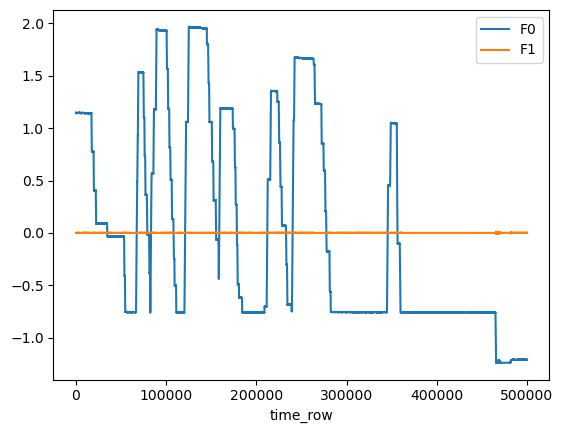

Признак column2



,F0,F1
time_row,,
0,0.969891,0.000153
1,0.970217,-0.000477
2,0.970368,0.000976
3,0.970738,-0.001694
4,0.971479,0.002041
...,...,...
499994,-1.560072,0.000278
499995,-1.558957,-0.000273
499996,-1.558785,0.001210


,F0,F1
count,4.999990e+05,4.999990e+05
mean,-9.486169e-10,9.486168e-10
std,9.999998e-01,1.167844e-03
min,-2.242693e+00,-5.115487e-02
25%,-9.429447e-01,-7.428931e-04
50%,6.521373e-02,-3.632832e-13
75%,8.172342e-01,7.461868e-04
max,2.051431e+00,2.690657e-02


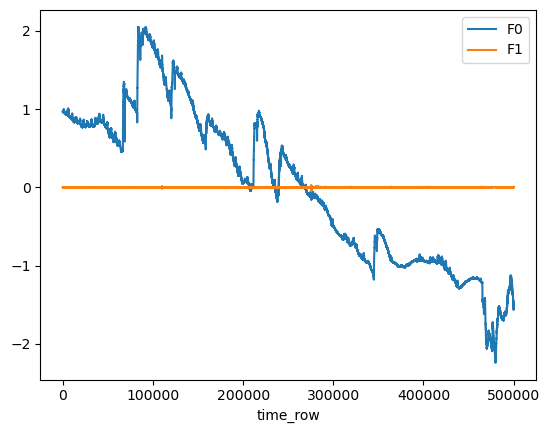

Признак column3



,F0,F1
time_row,,
0,-0.991185,2.185775e-03
1,-0.993370,8.440199e-11
2,-0.997742,-2.759121e-14
3,-0.999927,-2.185612e-03
4,-0.997742,-2.651113e-14
...,...,...
499994,1.397689,3.792321e-14
499995,1.214098,1.835914e-01
499996,0.663324,-6.608603e-14


,F0,F1
count,4.999990e+05,4.999990e+05
mean,3.649979e-07,-3.649979e-07
std,9.999989e-01,1.008565e-03
min,-2.064320e+00,-3.671830e-01
25%,-8.447486e-01,-2.363200e-14
50%,-1.858723e-02,-3.439089e-16
75%,1.016300e+00,2.760471e-14
max,2.066487e+00,1.835914e-01


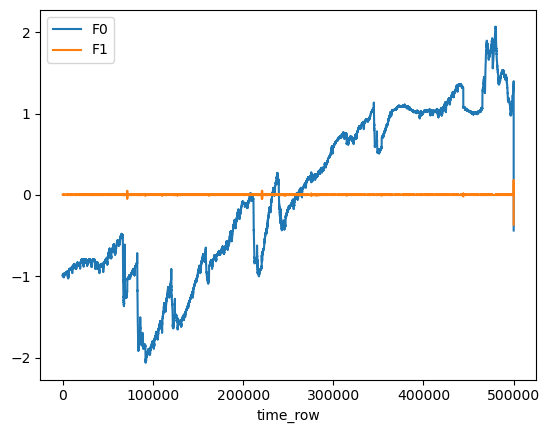

In [24]:
# Раскладываем на компоненты, выбираем рекомендуемый для тестирования и минимальных промежутков размер окна L
# Признак column1
print('Признак column1\n')
ssa_df_column1 = SSA(df['column1'], 2, save_mem=True)
components_df_column1 = ssa_df_column1.components_to_df()
display(components_df_column1)
display(components_df_column1.describe())
components_df_column1.plot()
plt.show()

# Признак column2
print('Признак column2\n')
ssa_df_column2 = SSA(df['column2'], 2, save_mem=True)
components_df_column2 = ssa_df_column2.components_to_df()
display(components_df_column2)
display(components_df_column2.describe())
components_df_column2.plot()
plt.show()

# Признак column3
print('Признак column3\n')
ssa_df_column3 = SSA(df['column3'], 2, save_mem=True)
components_df_column3 = ssa_df_column3.components_to_df()
display(components_df_column3)
display(components_df_column3.describe())
components_df_column3.plot()
plt.show()

### 2.3.2 Исследование основных компонентов признаков

#### 2.3.2.1 Проверка на стационарность

In [25]:
# Проведение проверки на стационарность тестом Дики-Фуллера
# Признак column1
adf_test_column1_main = adfuller(components_df_column1['F0'])
print(f'P-value Дики-Фуллера для признака column1 составило {adf_test_column1_main[1]}')

# Признак column2
adf_test_column2_main = adfuller(components_df_column2['F0'])
print(f'P-value Дики-Фуллера для признака column2 составило {adf_test_column2_main[1]}')

# Признак column3
adf_test_column3_main = adfuller(components_df_column3['F0'])
print(f'P-value Дики-Фуллера для признака column3 составило {adf_test_column3_main[1]}')

P-value Дики-Фуллера для признака column1 составило 0.07781143878450775
P-value Дики-Фуллера для признака column2 составило 0.9138941447573495
P-value Дики-Фуллера для признака column3 составило 0.6813859548552059


При значении Дики-Фуллера p-value < 0.05 ряд стационарен, если p-value >= 0.05, то ряд нестационарен.

Исходя из полученных показателей p-value можно сделать выводы:
- ряды не стационарны,
- характеристики рядов нестабильны,
- данные не предсказуемы, а модели на их основе могут быть нестабильнми и неточными.

#### 2.3.2.2 Проведение автокорреляционного анализа

Признак column1



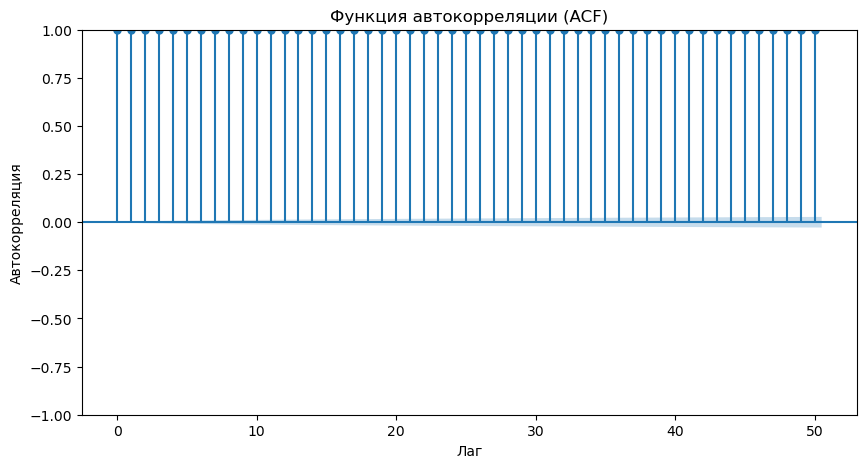

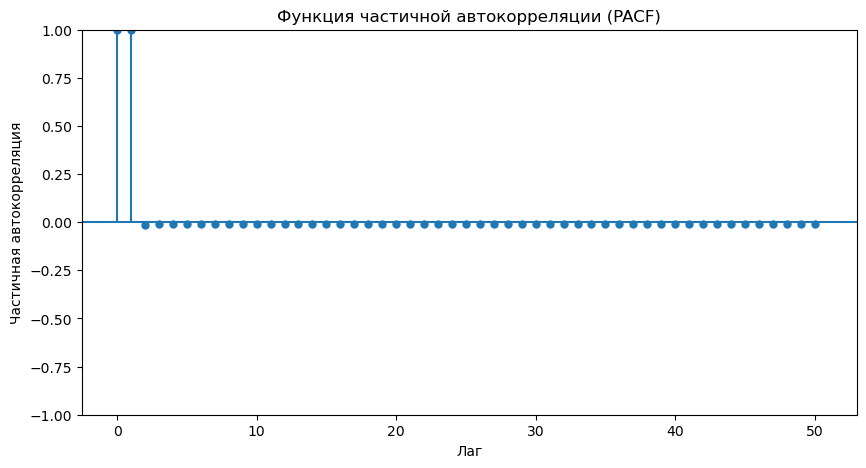

Признак column2



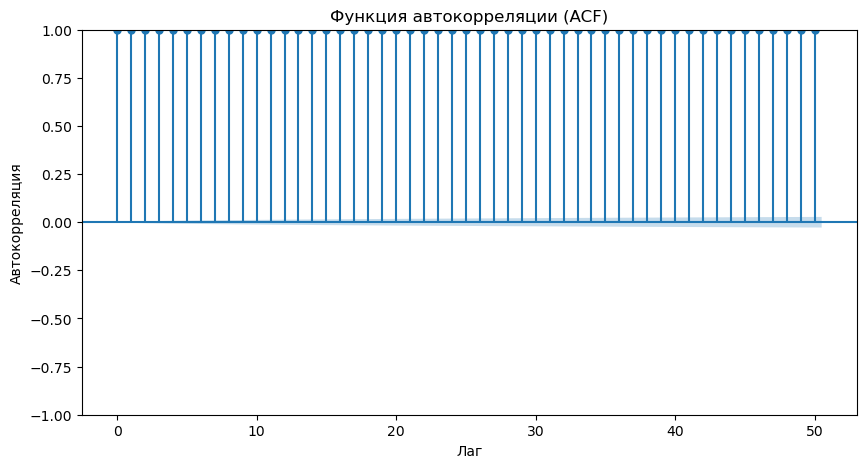

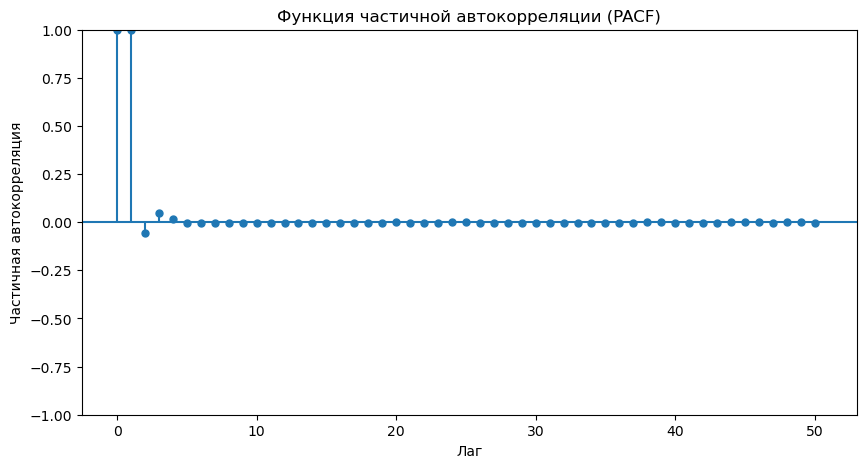

Признак column3



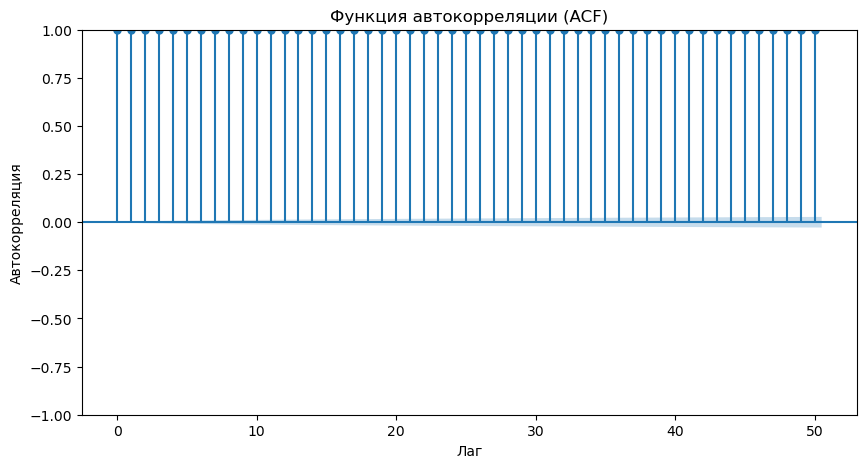

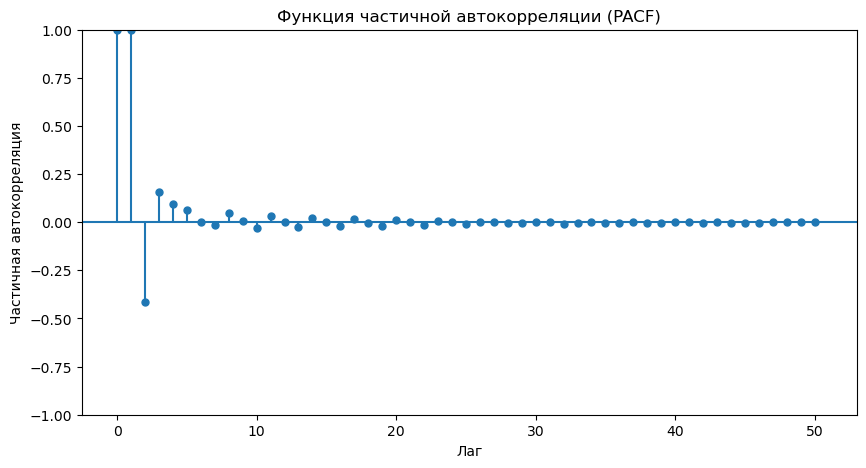

In [26]:
# Проведение автокорреляционного анализа
# Признак column1
print('Признак column1\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_column1['F0'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_column1['F0'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

# Признак column2
print('Признак column2\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_column2['F0'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_column2['F0'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

# Признак column3
print('Признак column3\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_column3['F0'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_column3['F0'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

По графикам можно сделать следующие выводы:
1. Есть признаки сильного тренда,
2. Есть признаки сильной нестационарности(https://stats.stackexchange.com/questions/606266/interpreting-acf-and-partial-acf-plots-with-python).

#### 2.3.2.3 Проведение частотного анализа Фурье

Первый признак column1



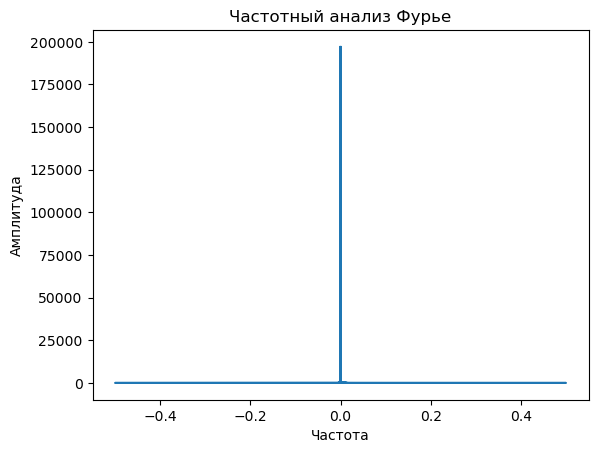

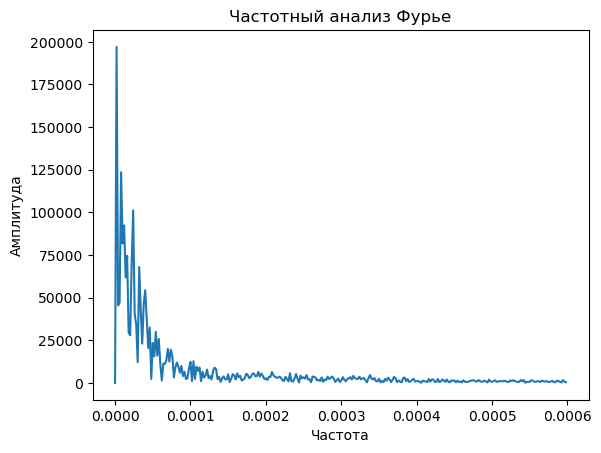

Второй признак column2



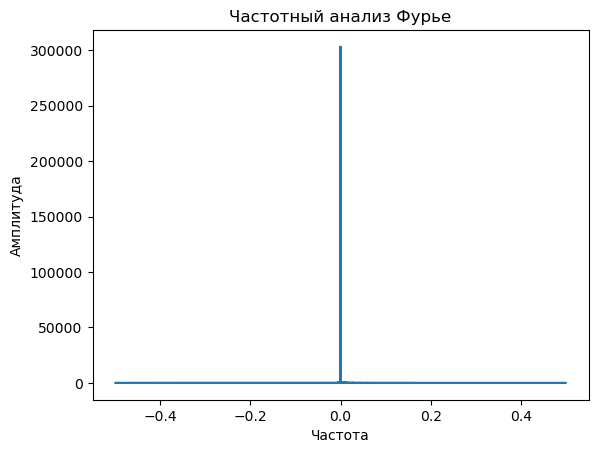

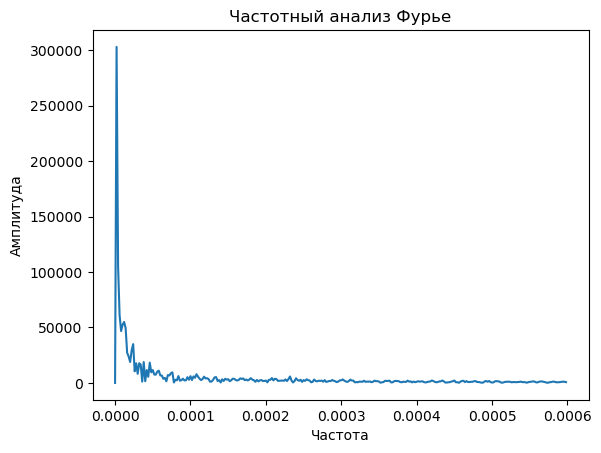

Третий признак column3



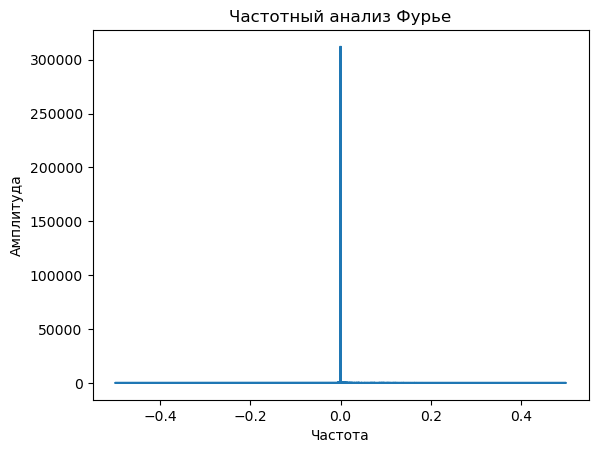

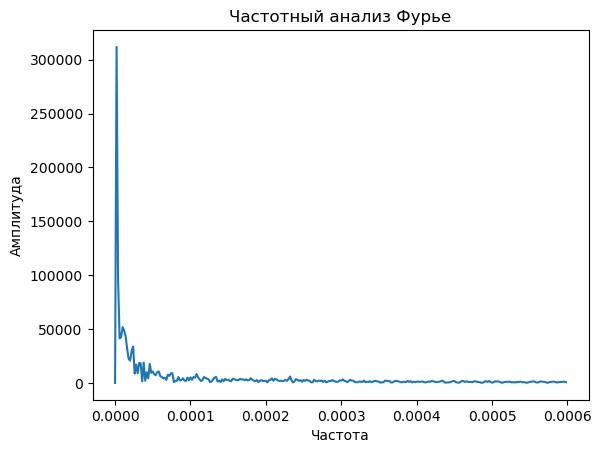

In [27]:
# Проведение частотного анализа Фурье
# Первый признак
print('Первый признак column1\n')
fft_values_column1_main = fft(np.array(components_df_column1['F0']))
fft_frequencies_column1_main = fftfreq(len(components_df_column1['F0']))
amplitude_spectrum1 = np.abs(fft_values_column1_main)
plt.plot(fft_frequencies_column1_main, amplitude_spectrum1)
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()
# Приблизим данные
plt.plot(fft_frequencies_column1_main[:300], amplitude_spectrum1[:300])
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()

# Второй признак
print('Второй признак column2\n')
fft_values_column2_main = fft(np.array(components_df_column2['F0']))
fft_frequencies_column2_main = fftfreq(len(components_df_column2['F0']))
amplitude_spectrum2 = np.abs(fft_values_column2_main)
plt.plot(fft_frequencies_column2_main, amplitude_spectrum2)
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()
# Приблизим данные
plt.plot(fft_frequencies_column2_main[:300], amplitude_spectrum2[:300])
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()

# Третий признак
print('Третий признак column3\n')
fft_values_column3_main = fft(np.array(components_df_column3['F0']))
fft_frequencies_column3_main = fftfreq(len(components_df_column3['F0']))
amplitude_spectrum3 = np.abs(fft_values_column3_main)
plt.plot(fft_frequencies_column3_main, amplitude_spectrum3)
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()
# Приблизим данные
plt.plot(fft_frequencies_column3_main[:300], amplitude_spectrum3[:300])
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()

Подобный пик может говорить о сильном тренде.

#### 2.3.2.4 Проведение тестов на нормальность распределения

In [28]:
# Проведем тест на нормальность
# Тест Шапиро-Уилка
# проверка характера распределения критерием Шапиро-Уилка
def shapiro_uilk(title, sample, alpha):
    """
    Критерий Шапиро-Уилка подтверждает или опровергает нормальность распределения.
    Принимает параметры:
    - title: string
        Название выборки.
    - sample: DataFrame
        Выборка.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: возможны искажения в выборках при n < 3 и n > 5000.
    """
    stat, p = st.shapiro(sample)
    if p < alpha:
        print(f'Статистика по выборке {title} - {stat}. P-value - {p}. Отклонить гипотезу о нормальности распределения.')
    else:
        print(f'Статистика по выборке {title} - {stat}. P-value - {p}. Принять гипотезу о нормальности распределения.')
    return stat, p

shapiro_uilk('column1', components_df_column1['F0'], 0.05)
shapiro_uilk('column2', components_df_column2['F0'], 0.05)
shapiro_uilk('column3', components_df_column3['F0'], 0.05)
# Тест на гомогенность дисперсий выборок
# Тест Левена
# проверка дисперсии на гомогенность - тест Левена
def test_leven(*samples, alpha):
    """
    Тест Левена подтверждает или опровергает гипотезу о гомогенности(схожесть) дисперсии выборок.
    Принимает параметры:
    - *samples: DataFrame
        Выборки.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: n >= 2.
    """
    stat, p = st.levene(*[np.asarray(s).flatten() for s in samples]) # DataFrame сворачивается в одномерный массив
    if p < alpha:
        print(f'Статистика Левена по выборкам - {stat}. P-value - {p}. Отвергаем гипотезу о гомогенности дисперсий выборок.')
    else:
        print(f'Статистика Левена по выборкам - {stat}. P-value - {p}. Принимаем гипотезу о гомогенности дисперсий выборок.')
    return stat, p

test_leven(components_df_column1['F0'], components_df_column2['F0'], components_df_column3['F0'], alpha=0.05)

Статистика по выборке column1 - 0.8318789005279541. P-value - 0.0. Отклонить гипотезу о нормальности распределения.
Статистика по выборке column2 - 0.9593647122383118. P-value - 0.0. Отклонить гипотезу о нормальности распределения.
Статистика по выборке column3 - 0.9443492293357849. P-value - 0.0. Отклонить гипотезу о нормальности распределения.
Статистика Левена по выборкам - 1436.8251697844585. P-value - 0.0. Отвергаем гипотезу о гомогенности дисперсий выборок.


C:\Users\FokinDV\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


(1436.8251697844585, 0.0)

Выборки распределены не нормально, дисперсии между выборками не гомогенны.

#### 2.3.2.5 Проведение анализа трендов и дисперсий

Первый признак column1



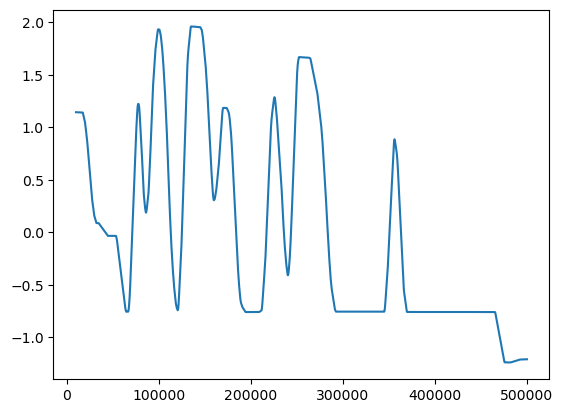

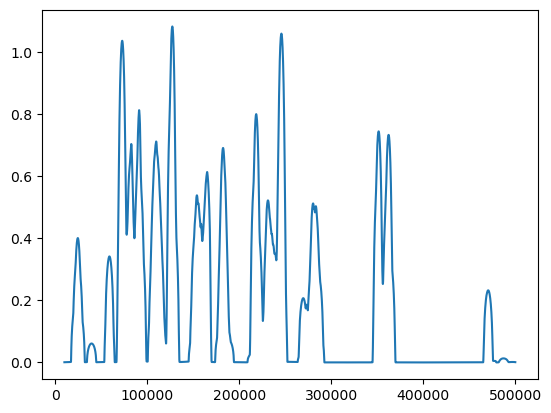

Второй признак column2



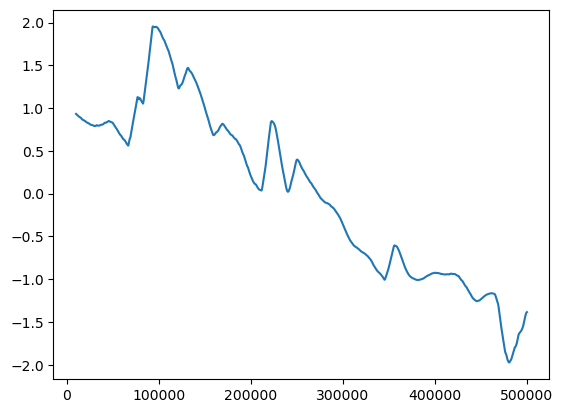

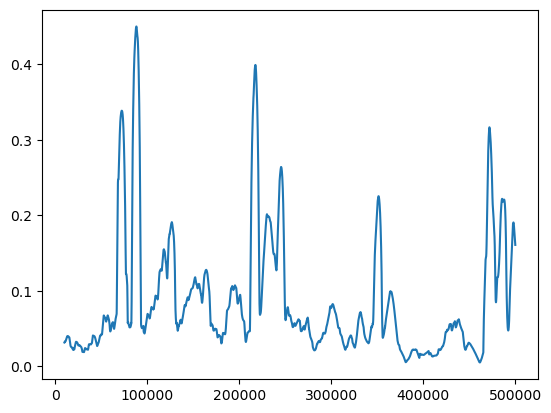

Третий признак column3



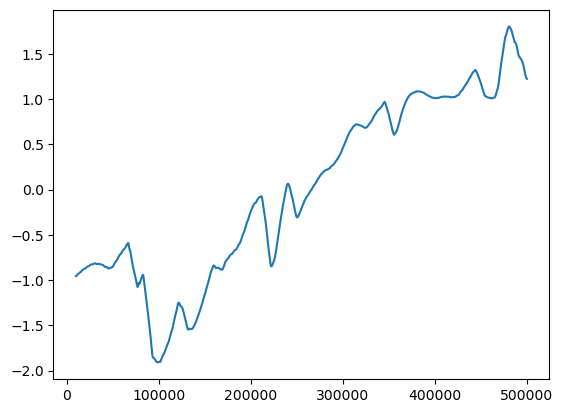

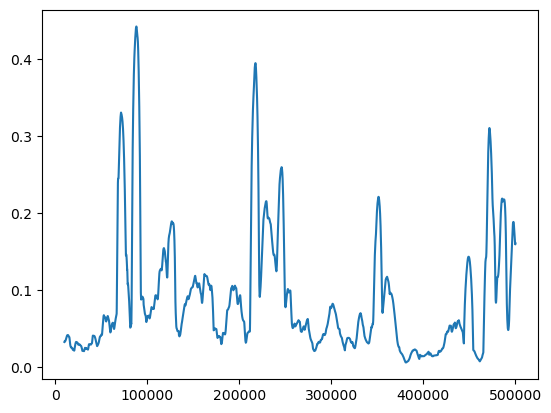

In [29]:
# Проанализируем тренды и изменения в дисперсии
# Построим скользящие средние
# Первый признак
print('Первый признак column1\n')
rolling_mean1 = components_df_column1['F0'].rolling(window=10000).mean()
plt.plot(rolling_mean1)
plt.show()
rolling_std1 = components_df_column1['F0'].rolling(window=10000).std()
plt.plot(rolling_std1)
plt.show()

# Второй признак
print('Второй признак column2\n')
rolling_mean2 = components_df_column2['F0'].rolling(window=10000).mean()
plt.plot(rolling_mean2)
plt.show()
rolling_std2 = components_df_column2['F0'].rolling(window=10000).std()
plt.plot(rolling_std2)
plt.show()

# Третий признак
print('Третий признак column3\n')
rolling_mean3 = components_df_column3['F0'].rolling(window=10000).mean()
plt.plot(rolling_mean3)
plt.show()
rolling_std3 = components_df_column3['F0'].rolling(window=10000).std()
plt.plot(rolling_std3)
plt.show()

Первый признак column1

Угол наклона(+восходящий тренд/-нисходящий) тренд: -0.00000
Сдвиг(точка пересечения с осью Y): 0.99086
Коэффициент корреляции между x и y: -0.57208
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.00000
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



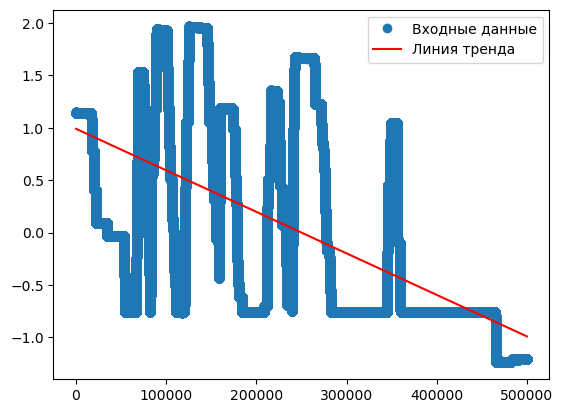

Второй признак column2

Угол наклона(+восходящий тренд/-нисходящий) тренд: -0.00001
Сдвиг(точка пересечения с осью Y): 1.59442
Коэффициент корреляции между x и y: -0.92054
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.00000
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



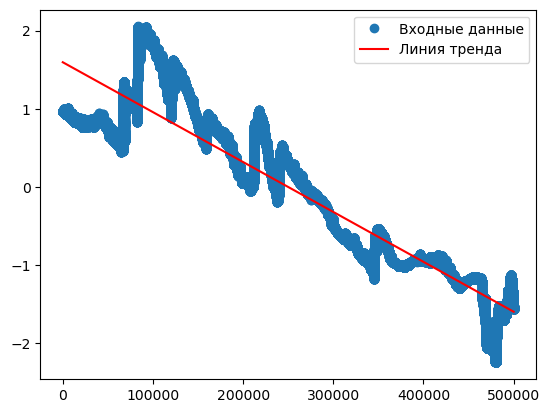

Третий признак column3

Угол наклона(+восходящий тренд/-нисходящий) тренд: 0.00001
Сдвиг(точка пересечения с осью Y): -1.59097
Коэффициент корреляции между x и y: 0.91855
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.00000
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



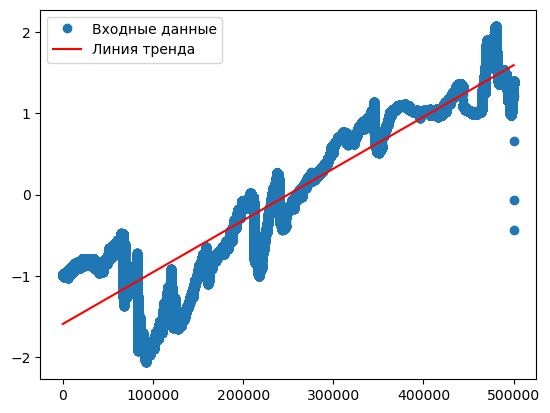

In [30]:
# Опредлим тренд линейной регрессией
# Первый признак
print('Первый признак column1\n')
x1 = np.arange(len(components_df_column1['F0']))
y1 = components_df_column1['F0'].values
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope1:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept1:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value1:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value1:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err1:.5f}\n')
plt.plot(x1, y1, 'o', label='Входные данные')
plt.plot(x1, intercept1 + slope1*x1, 'r', label='Линия тренда')
plt.legend()
plt.show()

# Второй признак
print('Второй признак column2\n')
x2 = np.arange(len(components_df_column2['F0']))
y2 = components_df_column2['F0'].values
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope2:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept2:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value2:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value2:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err2:.5f}\n')
plt.plot(x2, y2, 'o', label='Входные данные')
plt.plot(x2, intercept2 + slope2*x2, 'r', label='Линия тренда')
plt.legend()
plt.show()

# Третий признак
print('Третий признак column3\n')
x3 = np.arange(len(components_df_column3['F0']))
y3 = components_df_column3['F0'].values
slope3, intercept3, r_value3, p_value3, std_err3 = linregress(x3, y3)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope3:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept3:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value3:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value3:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err3:.5f}\n')
plt.plot(x3, y3, 'o', label='Входные данные')
plt.plot(x3, intercept3 + slope3*x3, 'r', label='Линия тренда')
plt.legend()
plt.show()

Оценка наличия тренда линейной регрессией:
1. Первый признак column1: тренд нисходящий, корреляция между временем и значением обратная сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная,
2. Второй признак column2: тренд нисходящий, корреляция между временем и значением обратная сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная,
3. Третий признак column3: тренд восходящий, корреляция между временем и значением прямая сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная.

#### 2.3.2.6 Оценка взаимосвязи основных компонентов признаков

##### 2.3.2.6.1 Построение матрицы корреляций по ключевым данным

Для проверки схожести/отличий между ключевыми элементами признаков - сформируем корреляционную матрицу.

In [31]:
# Склеиваем остатки признаков в один датафрейм
main_df_ssa = pd.DataFrame({'column1_F0': components_df_column1['F0'],
                             'column2_F0': components_df_column2['F0'],
                             'column3_F0': components_df_column3['F0']})
display(main_df_ssa.head(10))

,column1_F0,column2_F0,column3_F0
time_row,,,
0,1.146552,0.969891,-0.991185
1,1.146539,0.970217,-0.993370
2,1.146492,0.970368,-0.997742
3,1.146524,0.970738,-0.999927
4,1.146683,0.971479,-0.997742
5,1.146715,0.970576,-0.993370
6,1.146551,0.969700,-0.990092
7,1.146376,0.969716,-0.988999
8,1.146272,0.969354,-0.988999


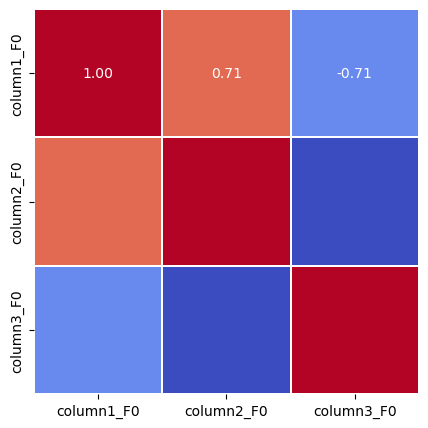

,column1_F0,column2_F0,column3_F0
column1_F0,1.000000,0.714712,-0.708752
column2_F0,0.714712,1.000000,-0.995640
column3_F0,-0.708752,-0.995640,1.000000


In [32]:
# Построим матрицу, выведем значения корреляций
plt.figure(figsize=(5,5))
sns.heatmap(main_df_ssa.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()
display(main_df_ssa.corr())

Корреляции между ключевыми данными признаков достаточно сильные.

##### 2.3.2.6.2 Обзор ключевых статистик по ключевым данным

In [33]:
# выведем ключевые статистики по трем признакам выборки
data = {'Статистика':['Среднее', 'Усеченное среднее', 'Медиана', 'Медианное абсолютное отклонение', 'Стандартное отклонение', 'Стандартная ошибка', 'Дисперсия'],
       'column1_F0':[main_df_ssa['column1_F0'].mean(),
                  trim_mean(main_df_ssa['column1_F0'], 0.1),
                  main_df_ssa['column1_F0'].median(),
                  mad(main_df_ssa['column1_F0']),
                  np.std(main_df_ssa['column1_F0'], ddof=1),
                  np.std(main_df_ssa['column1_F0'], ddof=1)/np.sqrt(len(main_df_ssa['column1_F0'])),
                  np.var(main_df_ssa['column1_F0'])],
       'column2_F0':[main_df_ssa['column2_F0'].mean(),
                  trim_mean(main_df_ssa['column2_F0'], 0.1),
                  main_df_ssa['column2_F0'].median(), mad(main_df_ssa['column2_F0']),
                  np.std(main_df_ssa['column2_F0'], ddof=1),
                  np.std(main_df_ssa['column2_F0'], ddof=1)/np.sqrt(len(main_df_ssa['column2_F0'])),
                  np.var(main_df_ssa['column2_F0'])],
       'column3_F0':[main_df_ssa['column3_F0'].mean(),
                  trim_mean(main_df_ssa['column3_F0'], 0.1),
                  main_df_ssa['column3_F0'].median(),
                  mad(main_df_ssa['column3_F0']),
                  np.std(main_df_ssa['column3_F0'], ddof=1),
                  np.std(main_df_ssa['column3_F0'], ddof=1)/np.sqrt(len(main_df_ssa['column3_F0'])),
                  np.var(main_df_ssa['column3_F0'])]}
data_table = pd.DataFrame(data)
data_table = data_table.round(5)
pivot_table = pd.pivot_table(data_table,
                             columns='Статистика',
                             values=['column1_F0', 'column2_F0', 'column3_F0'],
                            sort=False)
display(pivot_table)

Статистика,Среднее,Усеченное среднее,Медиана,Медианное абсолютное отклонение,Стандартное отклонение,Стандартная ошибка,Дисперсия
column1_F0,0.0,-0.09621,-0.70511,0.75047,1.0,0.00141,1.0
column2_F0,0.0,-0.01171,0.06521,1.25286,1.0,0.00141,1.0
column3_F0,0.0,0.02630,-0.01859,1.32208,1.0,0.00141,1.0


Среднее, стандартное отклонение, стандартная ошибка и дисперсия находятся на одном уровне друг с другом.
Медианное абсолютное отклонение второй и третьей выборки находятся достаточно близко друг к другу, схожесть между признаками присутствует.
Корреляции между данными присутствуют: прямая сильная между первым признаком и вторым - 0,71, обратная сильная между первым признаком и вторым - -0,71, обратная сильная корреляция между вторым и третьим признаками - -0,99.
Возможно предложить исключение второго или третьего признака для дальнейшего обучения модели по причине схожести этих данных.

### 2.3.3 Вывод

Основные компоненты были разложены при помощи SSA с коэффициентом разложения L=2, т.к. из ранее проведенного анализа был сделан вывод, что в данных присутствовал один основной влияющий признак и остатки, влияние которых достаточно низкое на основную тенденцию, но при этом в данных остатках могут скрываться некоторые аномалии, которые необходимо исследовать на следующем шаге данного EDA. 
Каждый основной компонент был проанализирован путем следующих проверок:
1. Проверка на стационарность:
    - ряды не стационарны,
    - характеристики рядов нестабильны,
    - данные не предсказуемы, а модели на их основе могут быть нестабильнми и неточными.
2. Автокорреляционный анализ:
    - есть признаки сильного тренда,
    - есть признаки сильной нестационарности.
3. Частотный анализ: пик может говорить о сильном тренде в признаках.
4. Тесты на нормальность, гомогенность: выборки распределены не нормально, дисперсии между выборками не гомогенны.
5. Анализ трендов и изменений в дисперсии:
    - скользящие средние: графики говорят о том, что есть слабый тренд, скользящие средние по стандартному отклонению второй и третьей выборки практически идентичны, поэтому можно говорить о схожести данных признаков и о возможности исключить один из них для дальнейшей работы,
    - линейная регрессия:
        - первый признак column1: тренд нисходящий, корреляция между временем и значением обратная сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная,
        - второй признак column2: тренд нисходящий, корреляция между временем и значением обратная сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная,
        - третий признак column3: тренд восходящий, корреляция между временем и значением прямая сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная.
6. Оценка взаимосвязи остаточных данных: среднее, стандартное отклонение, стандартная ошибка и дисперсия находятся на одном уровне друг с другом. Медианное абсолютное отклонение второй и третьей выборки находятся достаточно близко друг к другу, схожесть между признаками присутствует. Корреляции между данными присутствуют: прямая сильная между первым признаком и вторым - 0,71, обратная сильная между первым признаком и вторым - -0,71, обратная сильная корреляция между вторым и третьим признаками - -0,99. Возможно предложить исключение второго или третьего признака для дальнейшего обучения модели по причине схожести этих данных.

По итогам рассмотренных данных можно предположить, что лучшим вариантом для данных элементов признаков возможно использование трендовых моделей.


### 2.3.4 Исследование остатков компонентов признаков

В данном исследовании необходимо оценить параметры шумовых/остаточных признаков - F1, а также можно оценить их взаимосвязь между собой.

#### 2.3.4.1 Проверка на стационарность

In [34]:
# Проведение проверки на стационарность тестом Дики-Фуллера
# Признак column1
adf_test_column1_remain = adfuller(components_df_column1['F1'])
print(f'P-value Дики-Фуллера для признака column1 составило {adf_test_column1_remain[1]}')

# Признак column2
adf_test_column2_remain = adfuller(components_df_column2['F1'])
print(f'P-value Дики-Фуллера для признака column2 составило {adf_test_column2_remain[1]}')

# Признак column3
adf_test_column3_remain = adfuller(components_df_column3['F1'])
print(f'P-value Дики-Фуллера для признака column3 составило {adf_test_column3_remain[1]}')

P-value Дики-Фуллера для признака column1 составило 0.0
P-value Дики-Фуллера для признака column2 составило 0.0
P-value Дики-Фуллера для признака column3 составило 0.0


При значении Дики-Фуллера p-value < 0.05 ряд стационарен, если p-value >= 0.05, то ряд нестационарен.

Исходя из полученных показателей p-value можно сделать выводы:
- ряды стационарны,
- характеристики рядов стабильны,
- нельзя исключать предположение о предсказуемости данных, а модели на их основе могут быть стабильнми и точными.

#### 2.3.4.2 Проведение автокорреляционного анализа

Признак column1



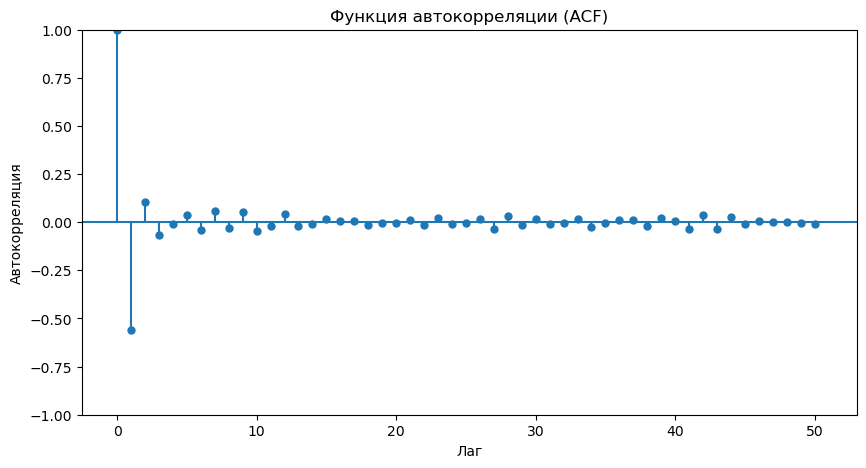

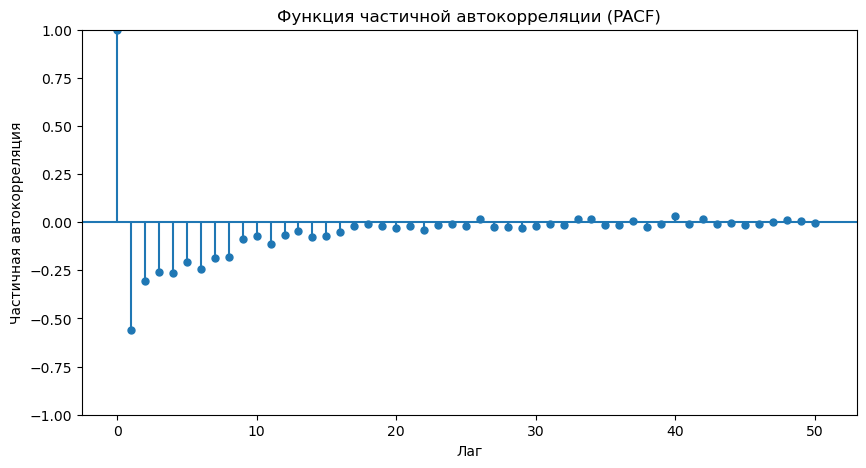

Признак column2



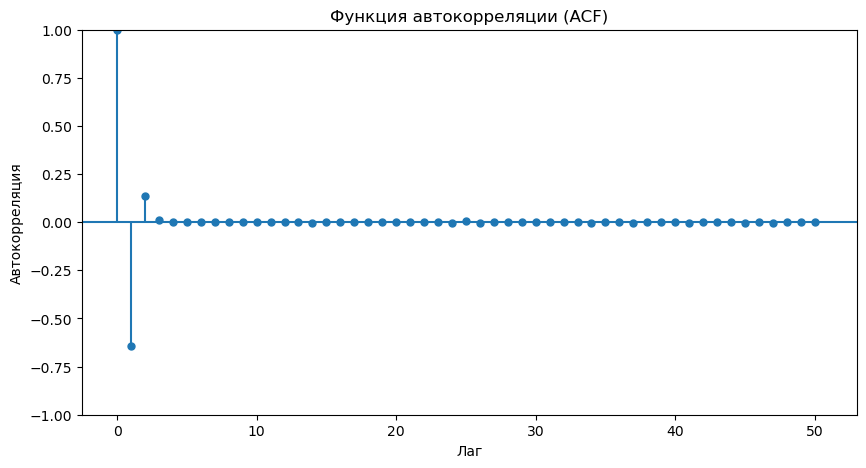

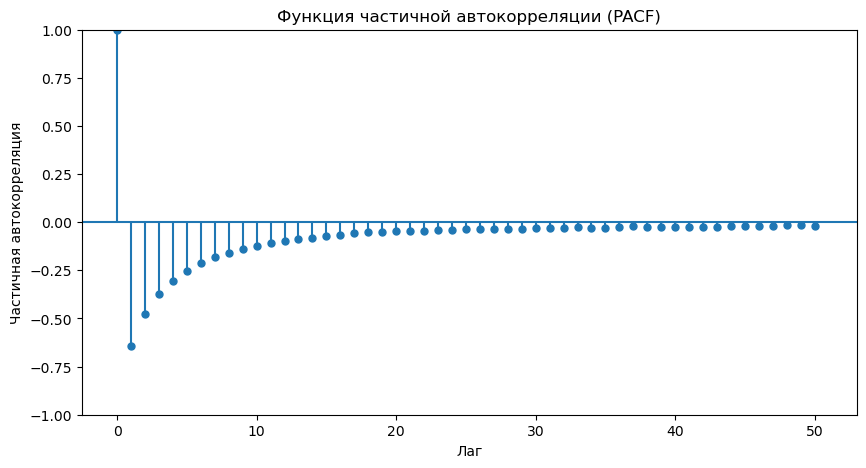

Признак column3



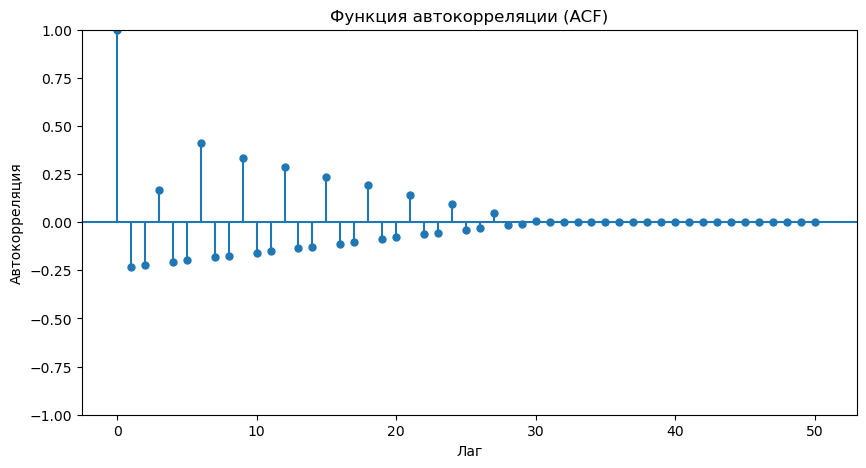

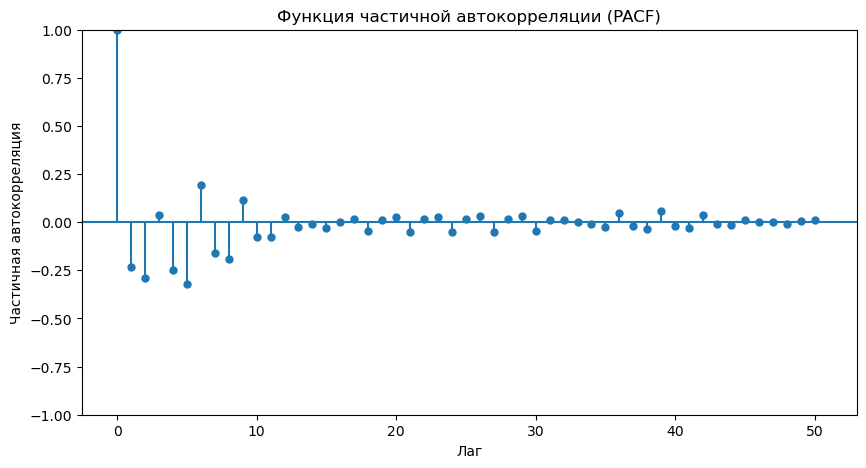

In [35]:
# Проведение автокорреляционного анализа
# Признак column1
print('Признак column1\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_column1['F1'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_column1['F1'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

# Признак column2
print('Признак column2\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_column2['F1'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_column2['F1'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

# Признак column3
print('Признак column3\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_column3['F1'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_column3['F1'], lags=50, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

Корреляция рядов с самими собой равна 1, затем происходит положительное или отрицательное затухание стремящееся к 0. 
По графикам можно сделать следующие выводы:
1. Характер распределения остатков похож на шум,
2. Признаков нестационарности нет.

#### 2.3.4.3 Проведение частотного анализа Фурье

Первый признак column1



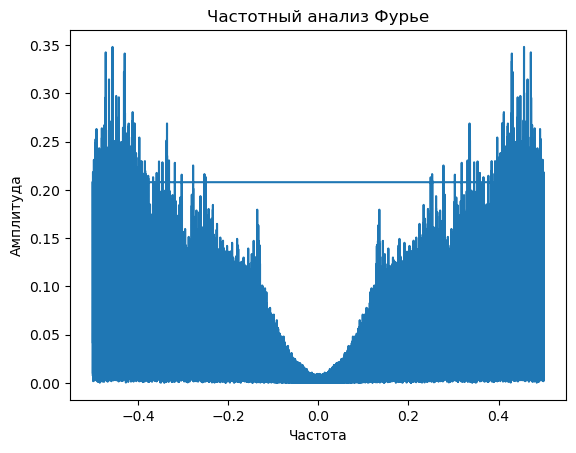

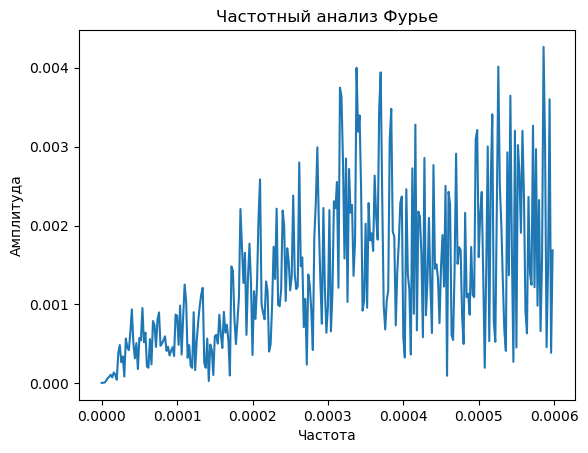

Второй признак column2



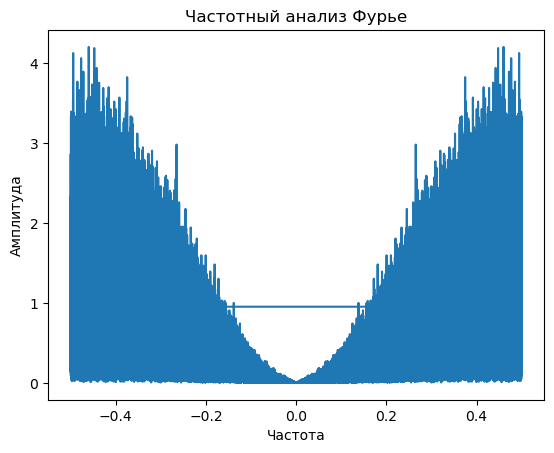

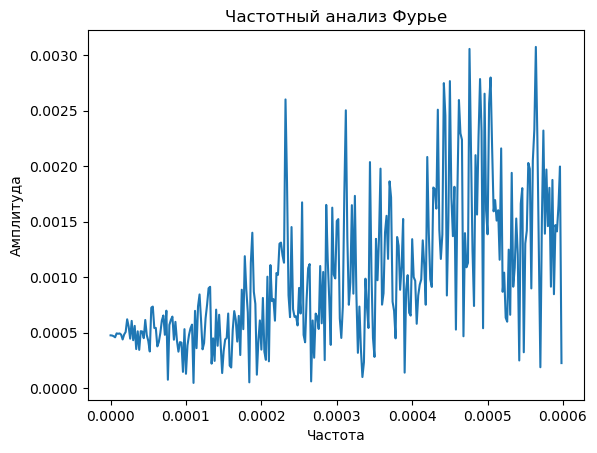

Третий признак column3



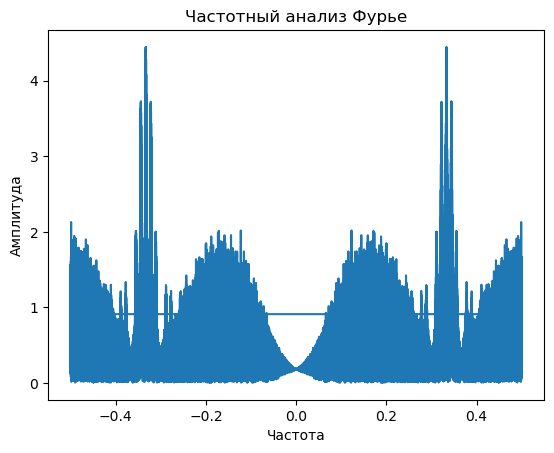

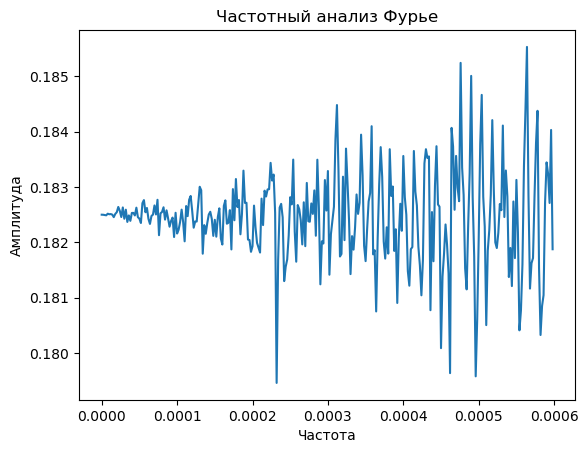

In [36]:
# Проведение частотного анализа Фурье
# Первый признак
print('Первый признак column1\n')
fft_values_column1_remain = fft(np.array(components_df_column1['F1']))
fft_frequencies_column1_remain = fftfreq(len(components_df_column1['F1']))
amplitude_spectrum1 = np.abs(fft_values_column1_remain)
plt.plot(fft_frequencies_column1_remain, amplitude_spectrum1)
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()
# Приблизим данные
plt.plot(fft_frequencies_column1_remain[:300], amplitude_spectrum1[:300])
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()

# Второй признак
print('Второй признак column2\n')
fft_values_column2_remain = fft(np.array(components_df_column2['F1']))
fft_frequencies_column2_remain = fftfreq(len(components_df_column2['F1']))
amplitude_spectrum2 = np.abs(fft_values_column2_remain)
plt.plot(fft_frequencies_column2_remain, amplitude_spectrum2)
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()
# Приблизим данные
plt.plot(fft_frequencies_column2_remain[:300], amplitude_spectrum2[:300])
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()

# Третий признак
print('Третий признак column3\n')
fft_values_column3_remain = fft(np.array(components_df_column3['F1']))
fft_frequencies_column3_remain = fftfreq(len(components_df_column3['F1']))
amplitude_spectrum3 = np.abs(fft_values_column3_remain)
plt.plot(fft_frequencies_column3_remain, amplitude_spectrum3)
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()
# Приблизим данные
plt.plot(fft_frequencies_column3_remain[:300], amplitude_spectrum3[:300])
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.title('Частотный анализ Фурье')
plt.show()

Исходя из графиков можно предположить, что шум может иметь какую-либо структуру(https://habr.com/ru/articles/196374/).

#### 2.3.4.4 Проведение тестов на нормальность распределения

In [37]:
# Проведем тест на нормальность
# Тест Шапиро-Уилка
# проверка характера распределения критерием Шапиро-Уилка
def shapiro_uilk(title, sample, alpha):
    """
    Критерий Шапиро-Уилка подтверждает или опровергает нормальность распределения.
    Принимает параметры:
    - title: string
        Название выборки.
    - sample: DataFrame
        Выборка.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: возможны искажения в выборках при n < 3 и n > 5000.
    """
    stat, p = st.shapiro(sample)
    if p < alpha:
        print(f'Статистика по выборке {title} - {stat}. P-value - {p}. Отклонить гипотезу о нормальности распределения.')
    else:
        print(f'Статистика по выборке {title} - {stat}. P-value - {p}. Принять гипотезу о нормальности распределения.')
    return stat, p

shapiro_uilk('column1', components_df_column1['F1'], 0.05)
shapiro_uilk('column2', components_df_column2['F1'], 0.05)
shapiro_uilk('column3', components_df_column3['F1'], 0.05)
# Тест на гомогенность дисперсий выборок
# Тест Левена
# проверка дисперсии на гомогенность - тест Левена
def test_leven(*samples, alpha):
    """
    Тест Левена подтверждает или опровергает гипотезу о гомогенности(схожесть) дисперсии выборок.
    Принимает параметры:
    - *samples: DataFrame
        Выборки.
    - alpha: float
        P-значение для заданной гипотезы.
    Возвращает параметры:
    - stat: float
        Статистика теста.
    - p: float
        P-значение рассчитанное для заданной гипотезы.
    Ограничения по размеру выборки: n >= 2.
    """
    stat, p = st.levene(*[np.asarray(s).flatten() for s in samples]) # DataFrame сворачивается в одномерный массив
    if p < alpha:
        print(f'Статистика Левена по выборкам - {stat}. P-value - {p}. Отвергаем гипотезу о гомогенности дисперсий выборок.')
    else:
        print(f'Статистика Левена по выборкам - {stat}. P-value - {p}. Принимаем гипотезу о гомогенности дисперсий выборок.')
    return stat, p

test_leven(components_df_column1['F1'], components_df_column2['F1'], components_df_column3['F1'], alpha=0.05)

Статистика по выборке column1 - 0.2954980134963989. P-value - 0.0. Отклонить гипотезу о нормальности распределения.
Статистика по выборке column2 - 0.9899377226829529. P-value - 0.0. Отклонить гипотезу о нормальности распределения.
Статистика по выборке column3 - 0.1002955436706543. P-value - 0.0. Отклонить гипотезу о нормальности распределения.
Статистика Левена по выборкам - 215970.62704364242. P-value - 0.0. Отвергаем гипотезу о гомогенности дисперсий выборок.


C:\Users\FokinDV\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


(215970.62704364242, 0.0)

Выборки распределены не нормально, дисперсии между выборками не гомогенны.

#### 2.3.4.5 Проведение анализа трендов и дисперсий

Первый признак column1



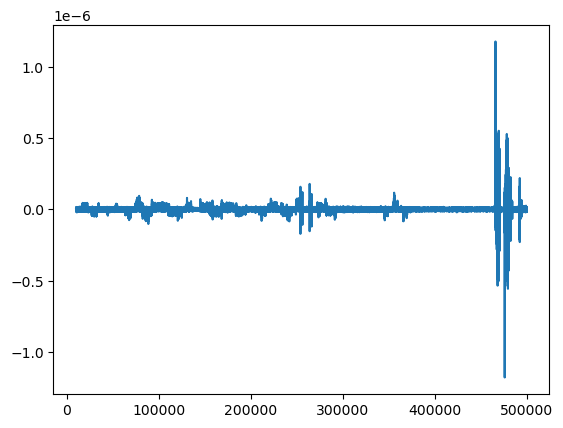

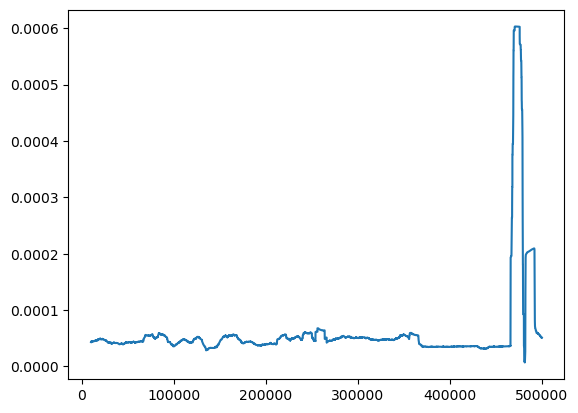

Второй признак column2



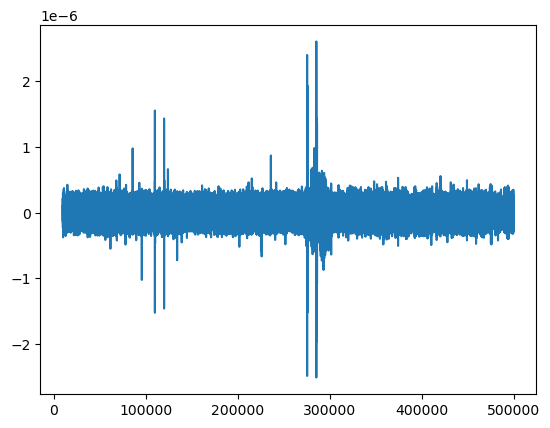

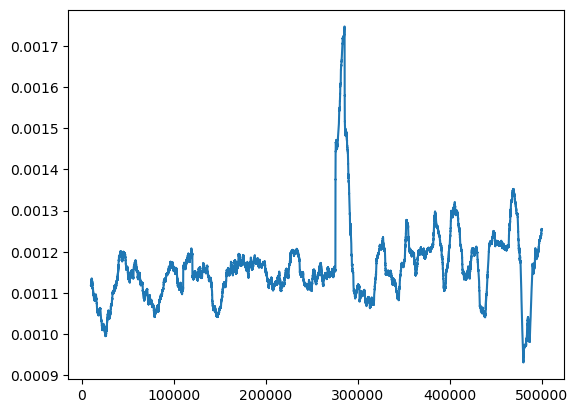

Третий признак column3



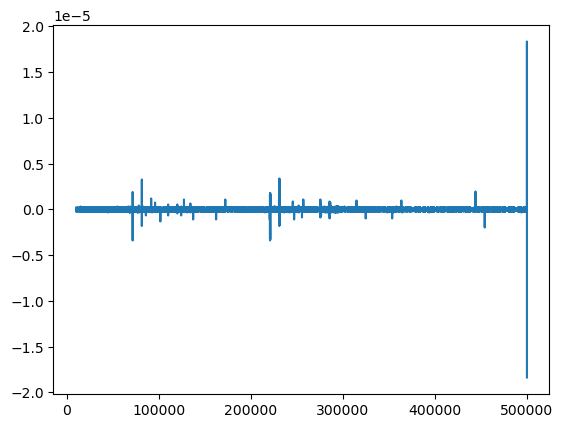

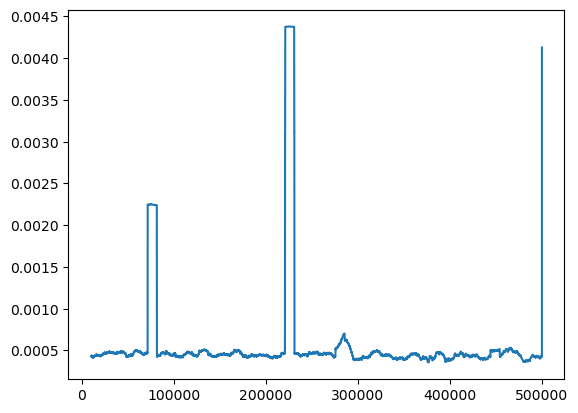

In [38]:
# Проанализируем тренды и изменения в дисперсии
# Построим скользящие средние
# Первый признак
print('Первый признак column1\n')
rolling_mean1 = components_df_column1['F1'].rolling(window=10000).mean()
plt.plot(rolling_mean1)
plt.show()
rolling_std1 = components_df_column1['F1'].rolling(window=10000).std()
plt.plot(rolling_std1)
plt.show()

# Второй признак
print('Второй признак column2\n')
rolling_mean2 = components_df_column2['F1'].rolling(window=10000).mean()
plt.plot(rolling_mean2)
plt.show()
rolling_std2 = components_df_column2['F1'].rolling(window=10000).std()
plt.plot(rolling_std2)
plt.show()

# Третий признак
print('Третий признак column3\n')
rolling_mean3 = components_df_column3['F1'].rolling(window=10000).mean()
plt.plot(rolling_mean3)
plt.show()
rolling_std3 = components_df_column3['F1'].rolling(window=10000).std()
plt.plot(rolling_std3)
plt.show()

Первый признак column1

Угол наклона(+восходящий тренд/-нисходящий) тренд: -0.00000
Сдвиг(точка пересечения с осью Y): 0.00000
Коэффициент корреляции между x и y: -0.00000
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.99973
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



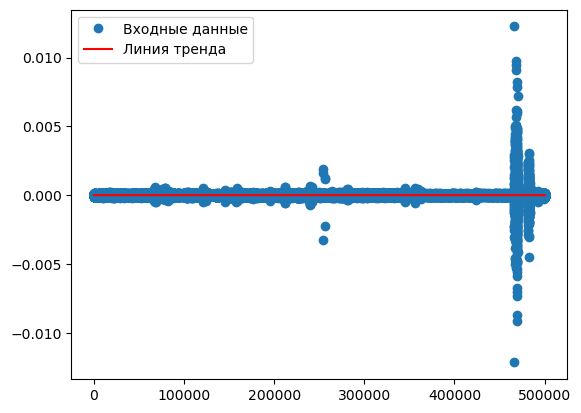

Второй признак column2

Угол наклона(+восходящий тренд/-нисходящий) тренд: 0.00000
Сдвиг(точка пересечения с осью Y): -0.00000
Коэффициент корреляции между x и y: 0.00000
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.99947
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



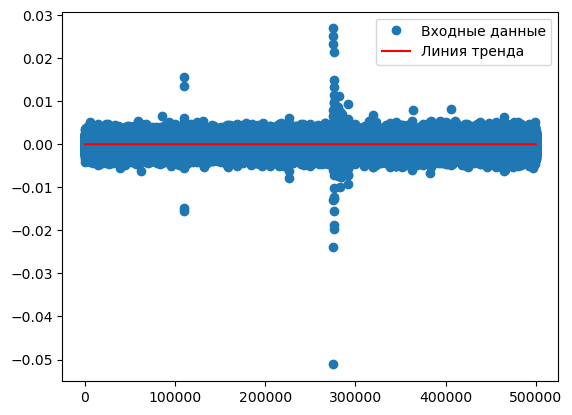

Третий признак column3

Угол наклона(+восходящий тренд/-нисходящий) тренд: -0.00000
Сдвиг(точка пересечения с осью Y): 0.00000
Коэффициент корреляции между x и y: -0.00063
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.65376
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



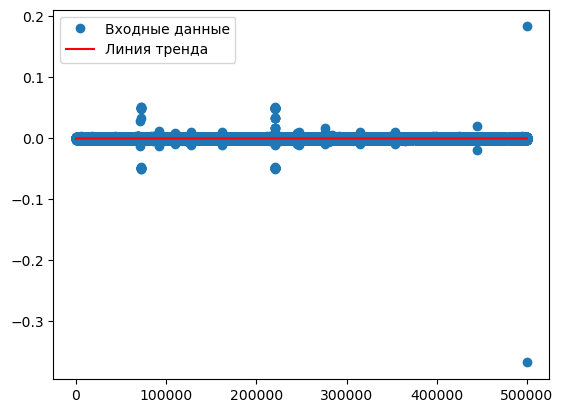

In [39]:
# Опредлим тренд линейной регрессией
# Первый признак
print('Первый признак column1\n')
x1 = np.arange(len(components_df_column1['F1']))
y1 = components_df_column1['F1'].values
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope1:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept1:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value1:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value1:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err1:.5f}\n')
plt.plot(x1, y1, 'o', label='Входные данные')
plt.plot(x1, intercept1 + slope1*x1, 'r', label='Линия тренда')
plt.legend()
plt.show()

# Второй признак
print('Второй признак column2\n')
x2 = np.arange(len(components_df_column2['F1']))
y2 = components_df_column2['F1'].values
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope2:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept2:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value2:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value2:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err2:.5f}\n')
plt.plot(x2, y2, 'o', label='Входные данные')
plt.plot(x2, intercept2 + slope2*x2, 'r', label='Линия тренда')
plt.legend()
plt.show()

# Третий признак
print('Третий признак column3\n')
x3 = np.arange(len(components_df_column3['F1']))
y3 = components_df_column3['F1'].values
slope3, intercept3, r_value3, p_value3, std_err3 = linregress(x3, y3)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope3:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept3:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value3:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value3:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err3:.5f}\n')
plt.plot(x3, y3, 'o', label='Входные данные')
plt.plot(x3, intercept3 + slope3*x3, 'r', label='Линия тренда')
plt.legend()
plt.show()

Оценка наличия тренда линейной регрессией: по остаткам всех трех признаков статистическая значимость p-value > 0.05, можно сделать вывод, что тренда нет.

#### 2.3.4.6 Оценка взаимосвязи остаточных данных между признаками

##### 2.3.4.6.1 Построение матрицы корреляций по остаточным данным

Для проверки схожести/отличий между остаточными выборками признаков - сформируем корреляционную матрицу.

In [40]:
# Склеиваем остатки признаков в один датафрейм
remain_df_ssa = pd.DataFrame({'column1_F1': components_df_column1['F1'],
                             'column2_F1': components_df_column2['F1'],
                             'column3_F1': components_df_column3['F1']})
display(remain_df_ssa.head(10))

,column1_F1,column2_F1,column3_F1
time_row,,,
0,5.315895e-06,0.000153,2.185775e-03
1,8.046707e-06,-0.000477,8.440199e-11
2,1.232574e-05,0.000976,-2.759121e-14
3,-1.118532e-04,-0.001694,-2.185612e-03
4,8.422005e-05,0.002041,-2.651113e-14
5,7.091590e-05,-0.000745,-2.642027e-14
6,-2.977667e-05,-0.000578,1.092806e-03
7,-8.349646e-07,0.001008,-2.683430e-14
8,-3.928981e-05,-0.001060,-2.683430e-14


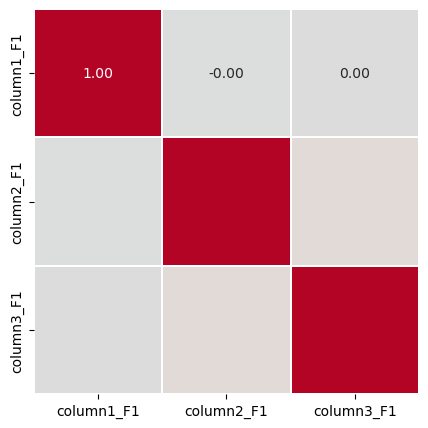

,column1_F1,column2_F1,column3_F1
column1_F1,1.000000,-0.002487,0.000298
column2_F1,-0.002487,1.000000,0.034938
column3_F1,0.000298,0.034938,1.000000


In [41]:
# Построим матрицу, выведем значения корреляций
plt.figure(figsize=(5,5))
sns.heatmap(remain_df_ssa.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()
display(remain_df_ssa.corr())

Корреляции между остаточными данными признаков практически полностью отсутствуют.

##### 2.3.4.6.2 Обзор ключевых статистик по остаточным данным

In [42]:
# выведем ключевые статистики по трем признакам выборки
data = {'Статистика':['Среднее', 'Усеченное среднее', 'Медиана', 'Медианное абсолютное отклонение', 'Стандартное отклонение', 'Стандартная ошибка', 'Дисперсия'],
       'column1_F1':[remain_df_ssa['column1_F1'].mean(),
                  trim_mean(remain_df_ssa['column1_F1'], 0.1),
                  remain_df_ssa['column1_F1'].median(),
                  mad(remain_df_ssa['column1_F1']),
                  np.std(remain_df_ssa['column1_F1'], ddof=1),
                  np.std(remain_df_ssa['column1_F1'], ddof=1)/np.sqrt(len(remain_df_ssa['column1_F1'])),
                  np.var(remain_df_ssa['column1_F1'])],
       'column2_F1':[remain_df_ssa['column2_F1'].mean(),
                  trim_mean(remain_df_ssa['column2_F1'], 0.1),
                  remain_df_ssa['column2_F1'].median(), mad(remain_df_ssa['column2_F1']),
                  np.std(remain_df_ssa['column2_F1'], ddof=1),
                  np.std(remain_df_ssa['column2_F1'], ddof=1)/np.sqrt(len(remain_df_ssa['column2_F1'])),
                  np.var(remain_df_ssa['column2_F1'])],
       'column3_F1':[remain_df_ssa['column3_F1'].mean(),
                  trim_mean(remain_df_ssa['column3_F1'], 0.1),
                  remain_df_ssa['column3_F1'].median(),
                  mad(remain_df_ssa['column3_F1']),
                  np.std(remain_df_ssa['column3_F1'], ddof=1),
                  np.std(remain_df_ssa['column3_F1'], ddof=1)/np.sqrt(len(remain_df_ssa['column3_F1'])),
                  np.var(remain_df_ssa['column3_F1'])]}
data_table = pd.DataFrame(data)
data_table = data_table.round(5)
pivot_table = pd.pivot_table(data_table,
                             columns='Статистика',
                             values=['column1_F1', 'column2_F1', 'column3_F1'],
                            sort=False)
display(pivot_table)

Статистика,Среднее,Усеченное среднее,Медиана,Медианное абсолютное отклонение,Стандартное отклонение,Стандартная ошибка,Дисперсия
column1_F1,0.0,0.0,0.0,0.00004,0.00010,0.0,0.0
column2_F1,0.0,0.0,0.0,0.00110,0.00117,0.0,0.0
column3_F1,0.0,0.0,0.0,0.00000,0.00101,0.0,0.0


Среднее, усеченное среднее, медиана, стандартная ошибка, дисперсия находятся на одном уровне друг с другом, близки к нулевым значениям, а медианное абсолютное отклонение, стандартное отклонение имеют значения незначительно больше 0, что говорит о том, что показатели колеблются вокруг нулевых значений, могут представлять характер случайного шума.
Корреляции между данными остатков практически полностью отсутствую, что говорит об отсутствии влияния изменений остатков/шума признаков друг на друга, а еще это указывает о корректном извлечении остатков методом SSA из предоставленных данных и о том, что связи между признаками скорее остались в F0 каждого признака.

### 2.3.5 Вывод

Основные компоненты были разложены при помощи SSA с коэффициентом разложения L=2, т.к. из ранее проведенного анализа был сделан вывод, что в данных присутствовал один основной влияющий признак и остатки, влияние которых достаточно низкое на основную тенденцию, но при этом в данных остатках могли скрываться некоторые аномалии, которые на данном этапе было необходимо исследовать. 
Каждый остаточный компонент был проанализирован путем следующих проверок:
1. Проверка на стационарность:
    - ряды стационарны,
    - характеристики рядов стабильны,
    - нельзя исключать предположение о предсказуемости данных, а модели на их основе могут быть стабильнми и точными.
2. Автокорреляционный анализ:
    - корреляция рядов с самими собой равна 1, затем происходит положительное или отрицательное затухание стремящееся к 0,
    - характер распределения остатков похож на шум,
    - признаков нестационарности нет.
3. Частотный анализ: исходя из графиков можно предположить, что шум может иметь какую-либо структуру.
4. Тесты на нормальность, гомогенность: выборки распределены не нормально, дисперсии между выборками не гомогенны.
5. Анализ трендов и изменений в дисперсии: по остаткам всех трех признаков статистическая значимость p-value > 0.05, можно сделать вывод, что тренда нет.
6. Оценка взаимосвязи остаточных данных: среднее, усеченное среднее, медиана, стандартная ошибка, дисперсия находятся на одном уровне друг с другом, близки к нулевым значениям, а медианное абсолютное отклонение, стандартное отклонение имеют значения незначительно больше 0, что говорит о том, что показатели колеблются вокруг нулевых значений, могут представлять характер случайного шума. Корреляции между данными остатков практически полностью отсутствую, что говорит об отсутствии влияния изменений остатков/шума признаков друг на друга, а еще это указывает о корректном извлечении остатков методом SSA из предоставленных данных и о том, что связи между признаками скорее остались в F0 каждого признака.

По итогам рассмотренных данных можно предположить, что лучшим вариантом для данных элементов признаков возможно использование моделей, которые могут предсказывать шум или какую-либо волатильность.

## 2.4 Проверка работы SSA и реконструкции признаков

Признак column1



,F0,F1
time_row,,
0,1.146552,0.000005
1,1.146539,0.000008
2,1.146492,0.000012
3,1.146524,-0.000112
4,1.146683,0.000084
...,...,...
499994,-1.210651,-0.000011
499995,-1.210734,-0.000080
499996,-1.210653,0.000007


,F0,F1
count,4.999990e+05,4.999990e+05
mean,1.229536e-11,-1.229552e-11
std,1.000001e+00,1.006391e-04
min,-1.239700e+00,-1.216076e-02
25%,-7.584945e-01,-2.721648e-05
50%,-7.051066e-01,-7.049404e-15
75%,1.049381e+00,2.711391e-05
max,1.967689e+00,1.225628e-02


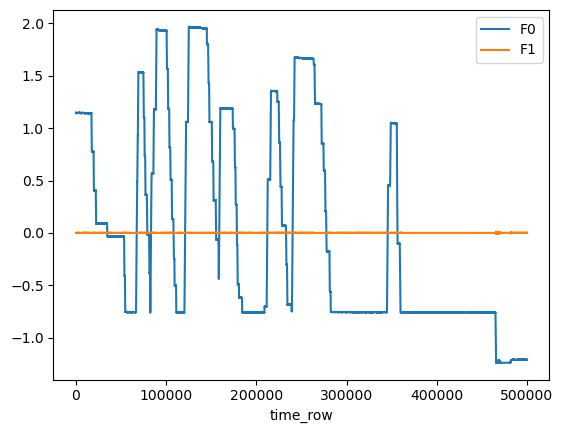

In [43]:
print('Признак column1\n')
ssa_df_column1 = SSA(df['column1'], 2, save_mem=True)
components_df_column1 = ssa_df_column1.components_to_df()
display(components_df_column1)
display(components_df_column1.describe())
components_df_column1.plot()
plt.show()

In [44]:
ssa_df_column1_reconstruct = ssa_df_column1.reconstruct(slice(0, ssa_df_column1.d))
ssa_df_column1_orig = ssa_df_column1.orig_TS
display(ssa_df_column1_reconstruct)
display(ssa_df_column1_orig)

time_row
0         1.146557
1         1.146547
2         1.146504
3         1.146412
4         1.146768
            ...   
499994   -1.210662
499995   -1.210814
499996   -1.210646
499997   -1.210505
499998   -1.210541
Length: 499999, dtype: float64

time_row
0         1.146557
1         1.146547
2         1.146504
3         1.146412
4         1.146768
            ...   
499994   -1.210662
499995   -1.210814
499996   -1.210646
499997   -1.210505
499998   -1.210541
Name: column1, Length: 499999, dtype: float64

In [45]:
# Реконструируем признаки и просмотрим на предмет сходства
# Признак column1
print('Признак column1\n')
ssa_df_column1_reconstruct = ssa_df_column1.reconstruct(slice(0, ssa_df_column1.d))
ssa_df_column1_orig = ssa_df_column1.orig_TS
display(ssa_df_column1_reconstruct.info())
display(ssa_df_column1_orig.info())

# Признак column2
print('Признак column2\n')
ssa_df_column2_reconstruct = ssa_df_column2.reconstruct(slice(0, ssa_df_column2.d))
ssa_df_column2_orig = ssa_df_column2.orig_TS
display(ssa_df_column2_reconstruct.info())
display(ssa_df_column2_orig.info())

# Признак column3
print('Признак column3\n')
ssa_df_column3_reconstruct = ssa_df_column3.reconstruct(slice(0, ssa_df_column3.d))
ssa_df_column3_orig = ssa_df_column3.orig_TS
display(ssa_df_column3_reconstruct.info())
display(ssa_df_column3_orig.info())

Признак column1

<class 'pandas.core.series.Series'>
Index: 499999 entries, 0 to 499998
Series name: None
Non-Null Count   Dtype  
--------------   -----  
499999 non-null  float64
dtypes: float64(1)
memory usage: 7.6 MB


None

<class 'pandas.core.series.Series'>
Index: 499999 entries, 0 to 499998
Series name: column1
Non-Null Count   Dtype  
--------------   -----  
499999 non-null  float64
dtypes: float64(1)
memory usage: 7.6 MB


None

Признак column2

<class 'pandas.core.series.Series'>
Index: 499999 entries, 0 to 499998
Series name: None
Non-Null Count   Dtype  
--------------   -----  
499999 non-null  float64
dtypes: float64(1)
memory usage: 7.6 MB


...

None

Признак column3

<class 'pandas.core.series.Series'>
Index: 499999 entries, 0 to 499998
Series name: None
Non-Null Count   Dtype  
--------------   -----  
499999 non-null  float64
dtypes: float64(1)
memory usage: 7.6 MB


None

<class 'pandas.core.series.Series'>
Index: 499999 entries, 0 to 499998
Series name: column3
Non-Null Count   Dtype  
--------------   -----  
499999 non-null  float64
dtypes: float64(1)
memory usage: 7.6 MB


None

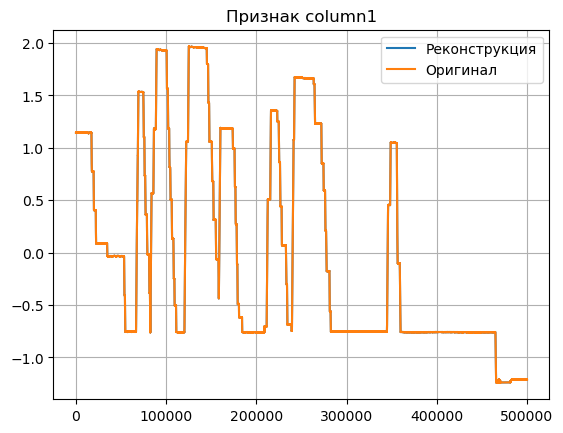

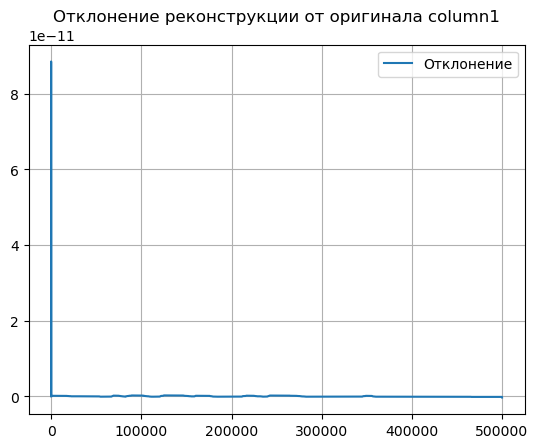

Значения метрик для признака column1
Среднее абсолютное отклонение предсказанных значений от фактических(средняя абсолютная ошибка)(MAE): 0.00
Среднеквадратическая ошибка(MSE): 0.00
Корень из среднеквадратической ошибки(RMSE): 0.00
Коэффициент детерминации(R-квадрат): 1.00


In [46]:
# Проверяем реконструкцию SSA первого признака
# Признак column1
plt.plot(ssa_df_column1_reconstruct, label='Реконструкция')
plt.plot(ssa_df_column1_orig, label='Оригинал')
plt.title('Признак column1')
plt.grid(True)
plt.legend()
plt.show()

# Отклонение
results = ssa_df_column1_orig.values - ssa_df_column1_reconstruct.values
plt.plot(results, label='Отклонение')
plt.title('Отклонение реконструкции от оригинала column1')
plt.grid(True)
plt.legend()
plt.show()

# Метрики
print('Значения метрик для признака column1')
print(f'Среднее абсолютное отклонение предсказанных значений от фактических(средняя абсолютная ошибка)(MAE): {mean_absolute_error(ssa_df_column1_orig, ssa_df_column1_reconstruct):.2f}')
print(f'Среднеквадратическая ошибка(MSE): {mean_squared_error(ssa_df_column1_orig, ssa_df_column1_reconstruct):.2f}')
print(f'Корень из среднеквадратической ошибки(RMSE): {mean_squared_error(ssa_df_column1_orig, ssa_df_column1_reconstruct, squared=False):.2f}')
print(f'Коэффициент детерминации(R-квадрат): {r2_score(ssa_df_column1_orig, ssa_df_column1_reconstruct):.2f}')

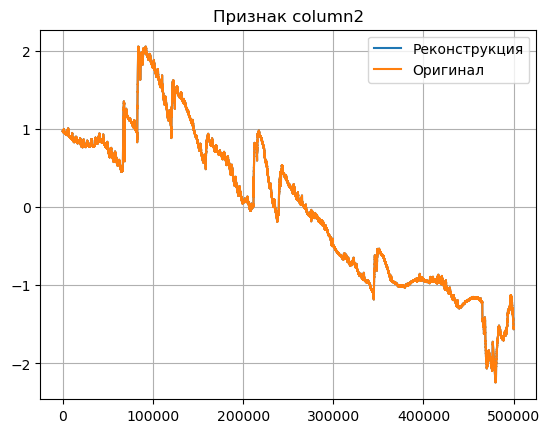

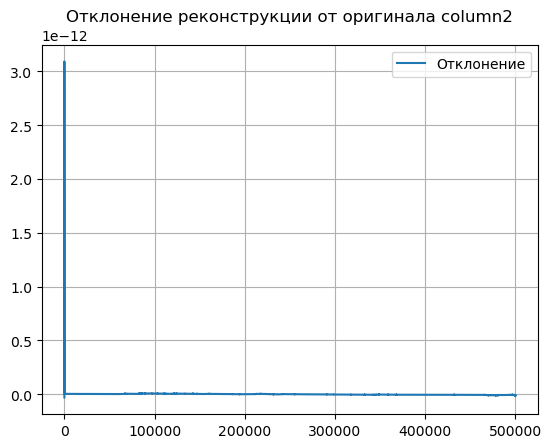

Значения метрик для признака column2
Среднее абсолютное отклонение предсказанных значений от фактических(средняя абсолютная ошибка)(MAE): 0.00
Среднеквадратическая ошибка(MSE): 0.00
Корень из среднеквадратической ошибки(RMSE): 0.00
Коэффициент детерминации(R-квадрат): 1.00


In [47]:
# Проверяем реконструкцию SSA второго признака
# Признак column2
plt.plot(ssa_df_column2_reconstruct, label='Реконструкция')
plt.plot(ssa_df_column2_orig, label='Оригинал')
plt.title('Признак column2')
plt.grid(True)
plt.legend()
plt.show()

# Отклонение
results = ssa_df_column2_orig.values - ssa_df_column2_reconstruct.values
plt.plot(results, label='Отклонение')
plt.title('Отклонение реконструкции от оригинала column2')
plt.grid(True)
plt.legend()
plt.show()

# Метрики
print('Значения метрик для признака column2')
print(f'Среднее абсолютное отклонение предсказанных значений от фактических(средняя абсолютная ошибка)(MAE): {mean_absolute_error(ssa_df_column2_orig, ssa_df_column2_reconstruct):.2f}')
print(f'Среднеквадратическая ошибка(MSE): {mean_squared_error(ssa_df_column2_orig, ssa_df_column2_reconstruct):.2f}')
print(f'Корень из среднеквадратической ошибки(RMSE): {mean_squared_error(ssa_df_column2_orig, ssa_df_column2_reconstruct, squared=False):.2f}')
print(f'Коэффициент детерминации(R-квадрат): {r2_score(ssa_df_column2_orig, ssa_df_column2_reconstruct):.2f}')

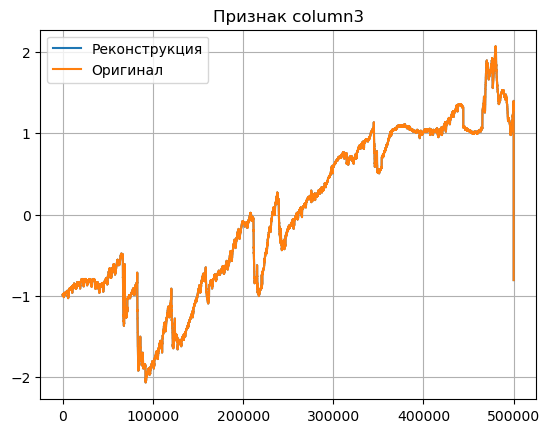

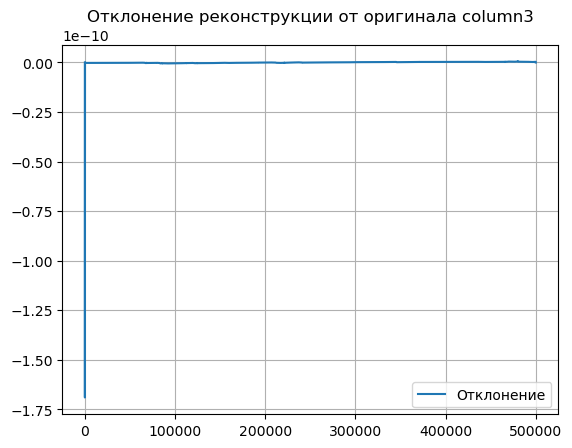

Значения метрик для признака column3
Среднее абсолютное отклонение предсказанных значений от фактических(средняя абсолютная ошибка)(MAE): 0.00
Среднеквадратическая ошибка(MSE): 0.00
Корень из среднеквадратической ошибки(RMSE): 0.00
Коэффициент детерминации(R-квадрат): 1.00


In [48]:
# Проверяем реконструкцию SSA третьего признака
# Признак column3
plt.plot(ssa_df_column3_reconstruct, label='Реконструкция')
plt.plot(ssa_df_column3_orig, label='Оригинал')
plt.title('Признак column3')
plt.grid(True)
plt.legend()
plt.show()

# Отклонение
results = ssa_df_column3_orig.values - ssa_df_column3_reconstruct.values
plt.plot(results, label='Отклонение')
plt.title('Отклонение реконструкции от оригинала column3')
plt.grid(True)
plt.legend()
plt.show()

# Метрики
print('Значения метрик для признака column3')
print(f'Среднее абсолютное отклонение предсказанных значений от фактических(средняя абсолютная ошибка)(MAE): {mean_absolute_error(ssa_df_column3_orig, ssa_df_column3_reconstruct):.2f}')
print(f'Среднеквадратическая ошибка(MSE): {mean_squared_error(ssa_df_column3_orig, ssa_df_column3_reconstruct):.2f}')
print(f'Корень из среднеквадратической ошибки(RMSE): {mean_squared_error(ssa_df_column3_orig, ssa_df_column3_reconstruct, squared=False):.2f}')
print(f'Коэффициент детерминации(R-квадрат): {r2_score(ssa_df_column3_orig, ssa_df_column3_reconstruct):.2f}')

## 2.5 Вывод

На данном этапе была осуществлена проверка корректности реконструкции SSA, т.к. это могло в дальнешем влиять на результат и с какой-либо вероятностью снижать показатели метрик.
Было выяснено, что модель SSA соответствует данным по каждому из признаков.

# 3 Общий вывод по EDA

По итогам этапа предварительного анализа было выявлено, что:
1. В данных отсутствуют пропуски и дублирования.
2. Стандартные ошибки, отклонения, дисперсии находятся достаточно близко друг к другу в указанных признаках,
3. Медианное абсолютное отклонение второго и третьего признаков находятся достаточно близко, можно предположить, что признаки имеют схожесть,
4. Корреляции: 
    - первый признак column1: сильная прямая корреляция со вторым признаком column2 - 0,71, сильная обратная корреляция с третьим признаком column3 - -0,71,
    - второй признак column2: сильная прямая корреляция с первым признаком column1 - 0,71, сильная обратная корреляция с третьим признаком column3 - -0,99,
    - третий признак column3: сильная обратная корреляция с первым признаком column1 - -0,71, сильная обратная корреляция со вторым признаком column2 - -0,99.

Сформировав класс для SSA анализа данных и применив его к данным, было выявлено, что 99% всех данных об изменениях и трендах находится в каждом первом элементе каждого признака, что говорит о том, что размер разбиения L=2 вполне корректен и позволяет отделить ключевые данные от шума/остатков.

Были исследованы основные ключевые части признаков и остатки, по результатам оценки этих данных были сделаны следующие выводы.

Основные компоненты были разложены при помощи SSA с коэффициентом разложения L=2, т.к. из ранее проведенного анализа был сделан вывод, что в данных присутствовал один основной влияющий признак и остатки, влияние которых достаточно низкое на основную тенденцию, но при этом в данных остатках могут скрываться некоторые аномалии. 
Каждый основной компонент был проанализирован путем следующих проверок:
1. Проверка на стационарность:
    - ряды не стационарны,
    - характеристики рядов нестабильны,
    - данные не предсказуемы, а модели на их основе могут быть нестабильнми и неточными.
2. Автокорреляционный анализ:
    - есть признаки сильного тренда,
    - есть признаки сильной нестационарности.
3. Частотный анализ: пик может говорить о сильном тренде в признаках.
4. Тесты на нормальность, гомогенность: выборки распределены не нормально, дисперсии между выборками не гомогенны.
5. Анализ трендов и изменений в дисперсии:
    - скользящие средние: графики говорят о том, что есть слабый тренд, скользящие средние по стандартному отклонению второй и третьей выборки практически идентичны, поэтому можно говорить о схожести данных признаков и о возможности исключить один из них для дальнейшей работы,
    - линейная регрессия:
        - первый признак column1: тренд нисходящий, корреляция между временем и значением обратная сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная,
        - второй признак column2: тренд нисходящий, корреляция между временем и значением обратная сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная,
        - третий признак column3: тренд восходящий, корреляция между временем и значением прямая сильная, значение p-value наклона низкое - наклон есть, стандартная ошибка наклона низкая - оценка наличия тренда достаточно правдоподобная.
6. Оценка взаимосвязи остаточных данных: среднее, стандартное отклонение, стандартная ошибка и дисперсия находятся на одном уровне друг с другом. Медианное абсолютное отклонение второй и третьей выборки находятся достаточно близко друг к другу, схожесть между признаками присутствует. Корреляции между данными присутствуют: прямая сильная между первым признаком и вторым - 0,71, обратная сильная между первым признаком и вторым - -0,71, обратная сильная корреляция между вторым и третьим признаками - -0,99. Возможно предложить исключение второго или третьего признака для дальнейшего обучения модели по причине схожести этих данных.

По итогам рассмотренных данных можно предположить, что лучшим вариантом для данных элементов признаков возможно использование трендовых моделей.

Каждый остаточный компонент был проанализирован путем следующих проверок:
1. Проверка на стационарность:
    - ряды стационарны,
    - характеристики рядов стабильны,
    - нельзя исключать предположение о предсказуемости данных, а модели на их основе могут быть стабильнми и точными.
2. Автокорреляционный анализ:
    - корреляция рядов с самими собой равна 1, затем происходит положительное или отрицательное затухание стремящееся к 0,
    - характер распределения остатков похож на шум,
    - признаков нестационарности нет.
3. Частотный анализ: исходя из графиков можно предположить, что шум может иметь какую-либо структуру.
4. Тесты на нормальность, гомогенность: выборки распределены не нормально, дисперсии между выборками не гомогенны.
5. Анализ трендов и изменений в дисперсии: по остаткам всех трех признаков статистическая значимость p-value > 0.05, можно сделать вывод, что тренда нет.
6. Оценка взаимосвязи остаточных данных: среднее, усеченное среднее, медиана, стандартная ошибка, дисперсия находятся на одном уровне друг с другом, близки к нулевым значениям, а медианное абсолютное отклонение, стандартное отклонение имеют значения незначительно больше 0, что говорит о том, что показатели колеблются вокруг нулевых значений, могут представлять характер случайного шума. Корреляции между данными остатков практически полностью отсутствую, что говорит об отсутствии влияния изменений остатков/шума признаков друг на друга, а еще это указывает о корректном извлечении остатков методом SSA из предоставленных данных и о том, что связи между признаками скорее остались в F0 каждого признака.

По итогам рассмотренных данных можно предположить, что лучшим вариантом для данных элементов признаков возможно использование моделей, которые могут предсказывать шум или какую-либо волатильность.

По итогам SSA анализа и разложения признаков на составляющие была осуществлена проверка корректности реконструкции SSA, т.к. это могло в дальнешем влиять на результат и с какой-либо вероятностью снижать показатели метрик. Было выяснено, что модель SSA соответствует данным по каждому из признаков.